# Original Script

## DepthCraft
## This project aims to create a 3D visual respresentation of a property from it's floor plan.

### This notebook serves as a document to showcase all the steps involved of the current approach.

### Importing libraries and supporting classes

In [1]:
pip install nnunetv2

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install -U flask-cors

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import uuid
from pathlib import Path
from typing import Dict, List, Set, Tuple, Any
from IPython.display import display
from concurrent.futures import ThreadPoolExecutor
from itertools import repeat

import numpy as np
from ultralytics import YOLO
from matplotlib import pyplot as plt
import cv2
from shapely import Polygon, prepared

from skimage.morphology import skeletonize
%matplotlib inline

sys.path.append('/home/ubuntu/repos/dc_ai_service')

from utils import read_image_adjust_dimensions, visualize_rooms_and_furniture, visualize_and_save_binary_image, \
visualize_yolo_detections
from model_loader import ModelLoader
from app import run_segmentation, run_ocr, run_yolo
from core.wall_engine import WallDetectorEngine
from core.opening_detector_engine import OpeningDetectorEngine
from core.plan_segmentation_engine import PlanSegmentorEngine
from core.room_classifier_engine import RoomClassifierEngine
from postprocess import process_walls_parallel, process_furniture_with_corners, calculate_scale_factor,\
filter_furniture_by_room_type, calculate_room_areas, populate_room_info, populate_walls, process_room_polygon,\
populate_corners, find_balcony_walls, update_balcony_walls

WARNING ⚠️ Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at '/home/ubuntu/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/home/ubuntu/miniconda/envs/floorplan/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-12 10:02:36,024 - app - INFO - Initializing ModelLoader...
2026-05-12 10:02:36,899 - root - INFO - Using downloaded & verified file: /home/ubuntu/.cache/doctr/models/fast_base-688a8b34.pt
2026-05-12 10:02:39,604 - root - INFO - Using downloaded & verified file: /home/ubuntu/.cache/doctr/models/crnn_vgg16_bn-0417f351.pt
2026-05-12 10:02:39,744 - root - INFO - Using downloaded & verified file: /home/ubuntu/.cache/doctr/models/mobilenet_v3_small_crop_orientation-f0847a18.pt
2026-05-12 10:02:39,846 - root - INFO - Using downloaded & verified file: /home/ubuntu/.cache/doctr/models/mobilenet_v3_small_page_orientation-8e60325c.pt
2026-05-12 10:03:03,655 - app - INFO - ModelLoader initialized successfully


### Setting paths

In [ ]:
BASE_DIR = Path('/home/ubuntu/repos/flp_test_work_2026/dc_ai_service')
IMG_PATH = BASE_DIR / 'test_images' / 'varun.jpg'
OUTPUT_PATH = BASE_DIR / 'test_output' / 'may_2026'
SEG_MODEL_PATH = BASE_DIR / 'checkpoints' / 'ckpt_fold_all'
YOLO_MODEL_PATH = BASE_DIR / 'checkpoints' / 'yolo.pt'

### Reading a floor plan

In [5]:
#img = cv2.imread(IMG_PATH)
img = open(IMG_PATH, 'rb')
img_array = read_image_adjust_dimensions(img)
print(img_array.shape)
# Process image efficiently
original_image = img_array.copy()

Original image shape- inside utils.py: (1280, 637, 3)
(3, 1, 1280, 637)


### Visualizing Input floor plan

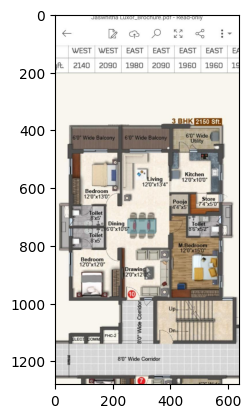

(3, 1, 1280, 637)

In [6]:
plt.figure()
plt.imshow(img_array.squeeze(1).transpose(1,2,0).astype(np.uint8))
fig = plt.gcf()
display(fig)
display(img_array.shape)

### Loading Deep Learning Model Class to load segmentation, YOLO and OCR models

In [7]:
model_loader_obj = ModelLoader()
predictor = model_loader_obj.get_predictor()
predictor.initialize_from_trained_model_folder(
            SEG_MODEL_PATH,
            use_folds=('all',),
            checkpoint_name='checkpoint_best.pth')
model_loader_obj.yolo_model = YOLO(YOLO_MODEL_PATH)

In [ ]:
print("Models loaded successfully.")
print(f"Predictor: {predictor}")
print(f"YOLO model: {model_loader_obj.yolo_model}")

### Running the models to generate the output

In [1]:
print(img_array.shape)
seg_output = run_segmentation(img_array)
print("Segmentation output", seg_output)
ocr_output = run_ocr(IMG_PATH)
print("OCR output", ocr_output)
yolo_output = run_yolo(img_array)
print("YOLO output", yolo_output)

NameError: name 'img_array' is not defined

### Raw Segmentation Result

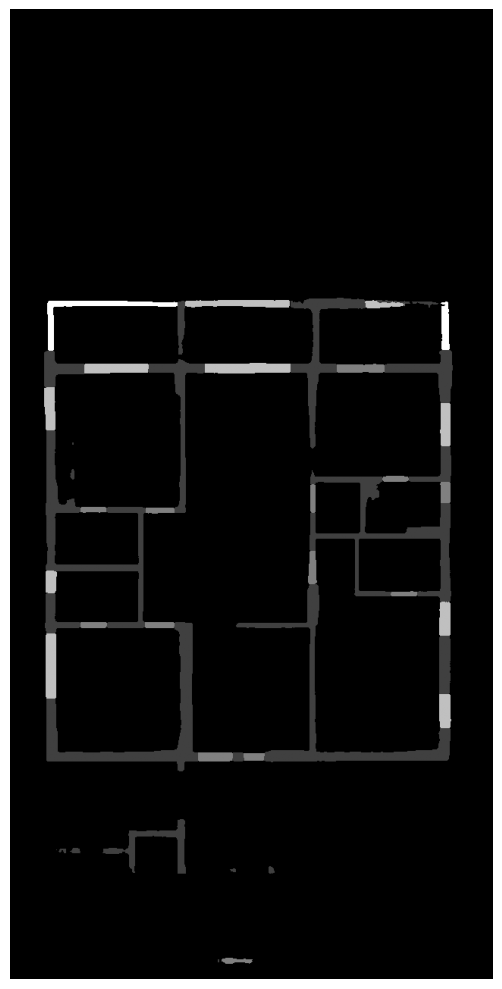

In [7]:
display(visualize_and_save_binary_image(seg_output[0][0], save_path=None))

### Raw Object Detection Result

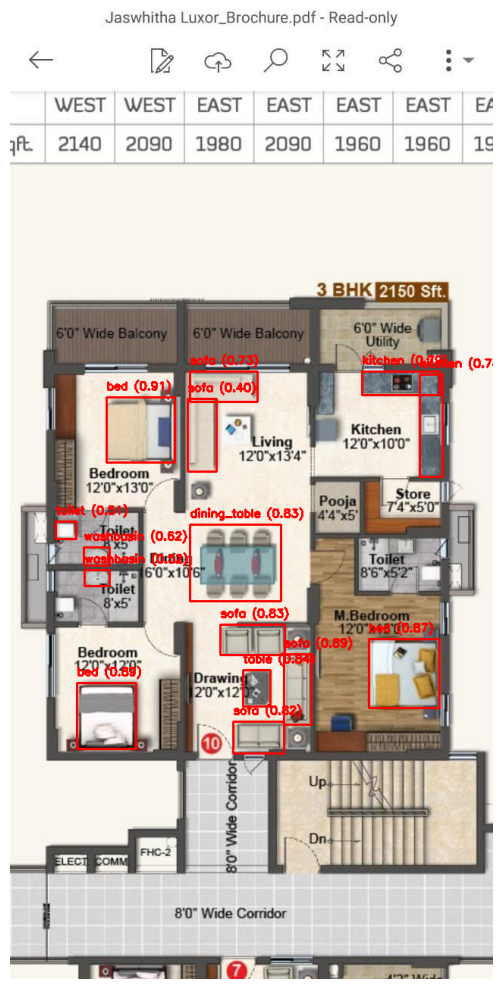

In [8]:
display(visualize_and_save_binary_image(visualize_yolo_detections(img_array.squeeze(1).transpose(1,2,0).astype(np.uint8), yolo_output), save_path=None))

### Step 1: Detect Walls

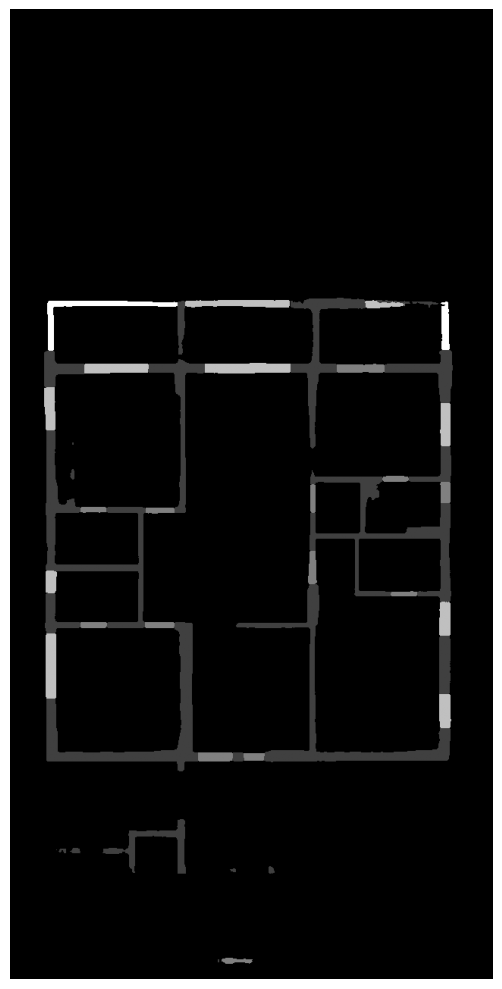

In [9]:
wall_engine = WallDetectorEngine(gap_ratio=0)
mask = seg_output[0][0]
display(visualize_and_save_binary_image(mask, save_path=None))

### Step 1.1 Clean Mask

#### The segmentation output is cleaned to remove noise, close gaps, and retain only the most relevant wall-like structures by using morphological operations and clustering based on area and elongation.

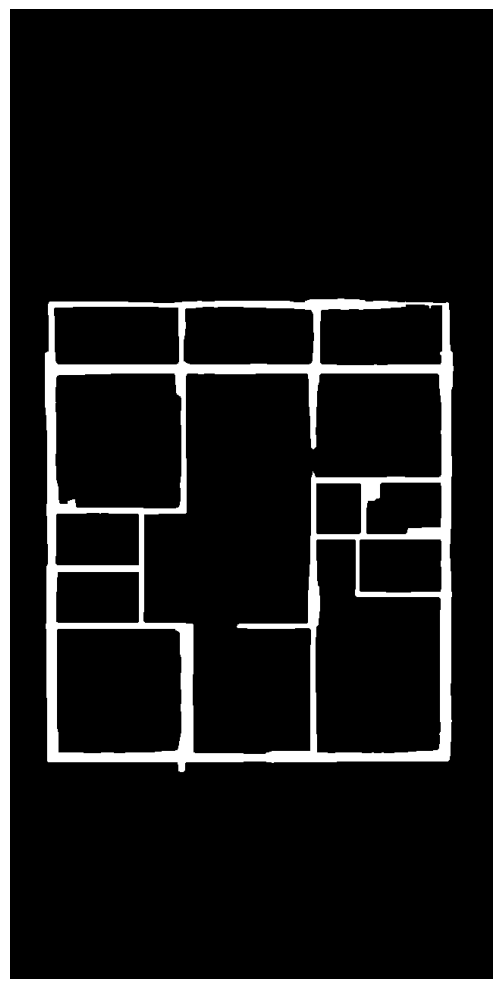

In [10]:
wall_engine.original_shape = mask.shape
binary = (mask > 0).astype(np.uint8)
cleaned = wall_engine._clean_mask(binary)
display(visualize_and_save_binary_image(cleaned, save_path=None))

### Step 1.2 Skeletonize

#### This is a simple operation to skeletonize the cleaned mask

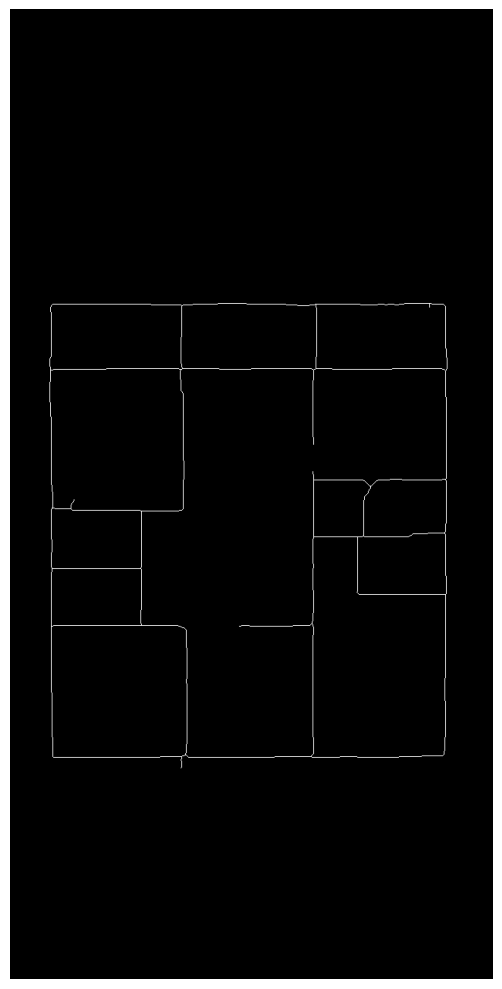

In [11]:
skel = skeletonize(cleaned > 0).astype(np.uint8)
display(visualize_and_save_binary_image(skel, save_path=None))

### Step 1.3 Skeleton to graph

#### The function converts a skeletonized image into a graph by identifying nodes (pixels with a degree ≠ 2) and edges (chains of connected pixels between nodes). It first computes the degree of each skeleton pixel, marking endpoints and junctions as nodes. Then, it traces paths between nodes, following skeleton pixels until another node or a dead-end is reached. Each traced path forms an edge, ensuring no duplicates. The function returns a graph as a dictionary of node coordinates and a list of edges with their pixel paths.

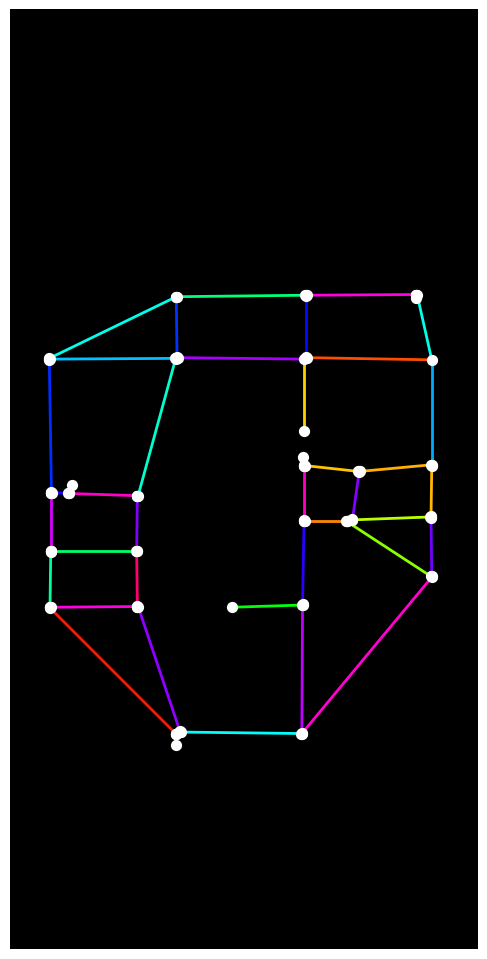

In [12]:
wall_engine.nodes, wall_engine.edges = wall_engine._skeleton_to_graph(skel)
display(
wall_engine.visualize(show_node_labels=False, 
                    show_wall_labels=False)
)

### Step 1.4 Simplify Edges

#### Here, the graph is reduced in complexity of edges by applying the Ramer-Douglas-Peucker (RDP) algorithm. It simplifies the pixel chains representing each edge, potentially adding intermediate nodes for long chains, and ensuring the edges are represented with fewer points while maintaining their overall shape

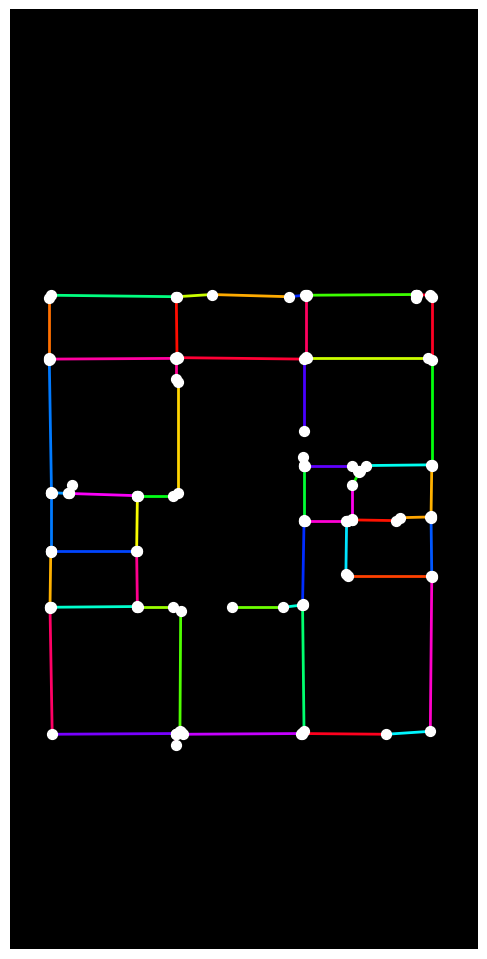

In [13]:
wall_engine.nodes, wall_engine.edges = wall_engine._simplify_edges(wall_engine.nodes, wall_engine.edges)
display(
wall_engine.visualize(show_node_labels=False, 
                    show_wall_labels=False)
)

### Step 1.5 Align the Graph Orthogonally

#### Now the graph is aligned orthogonally based on the assumption that walls are either parallel or orthogonal to each other. This is achieved by merging close points, aligning segments to be strictly horizontal or vertical, and merging parallel lines to simplify the graph structure while maintaining orthogonal alignment.

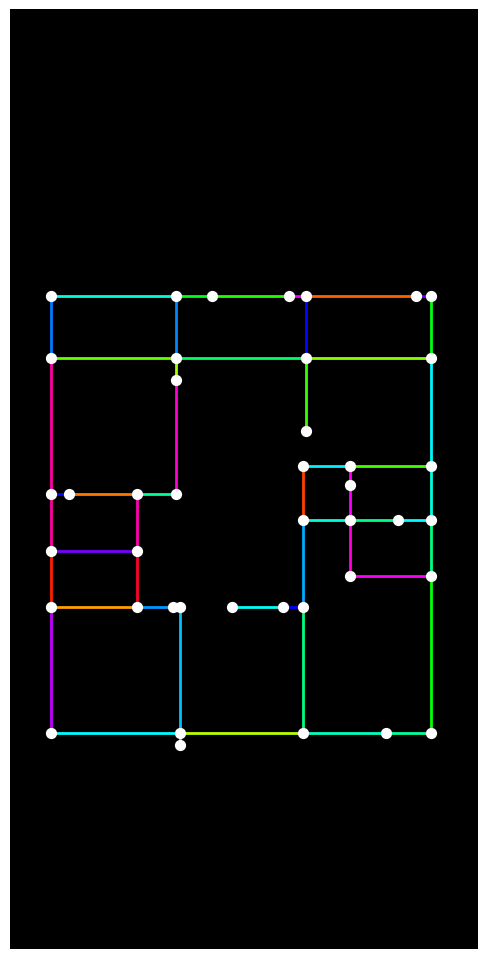

In [14]:
wall_engine.nodes, wall_engine.edges = wall_engine._align_graph_orthogonal(wall_engine.nodes, wall_engine.edges)
display(
wall_engine.visualize(show_node_labels=False, 
                    show_wall_labels=False)
)

### Step 1.6 Normalize Graph Nodes

#### This is a simple method to normalize the coordinates of the nodes.

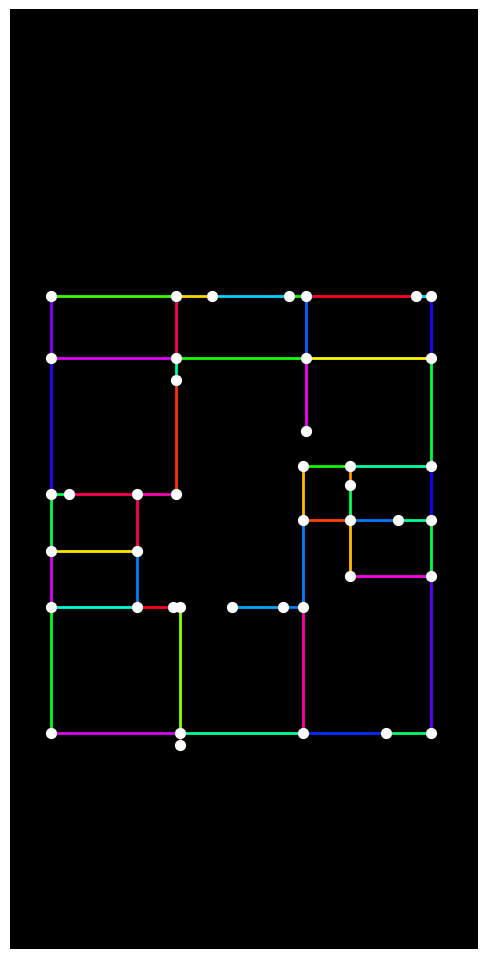

In [15]:
# NEW: Ensure coordinates are positive after initial processing
min_x, min_y = wall_engine._compute_min_coords()

if min_x < 0 or min_y < 0:
    wall_engine._normalize_nodes(min_x, min_y)
display(
wall_engine.visualize(show_node_labels=False, 
                    show_wall_labels=False)
)

### Step 1.7 Build Adjacency and Extend Walls
#### Here, using the graph an adjacency list and an edge lookup dictionary is created for the wall graph. Also the walls are extended by connecting closed nodes, merging redundant edges and realigning nodes to ensure orthogonality. The extension happens iteratively.

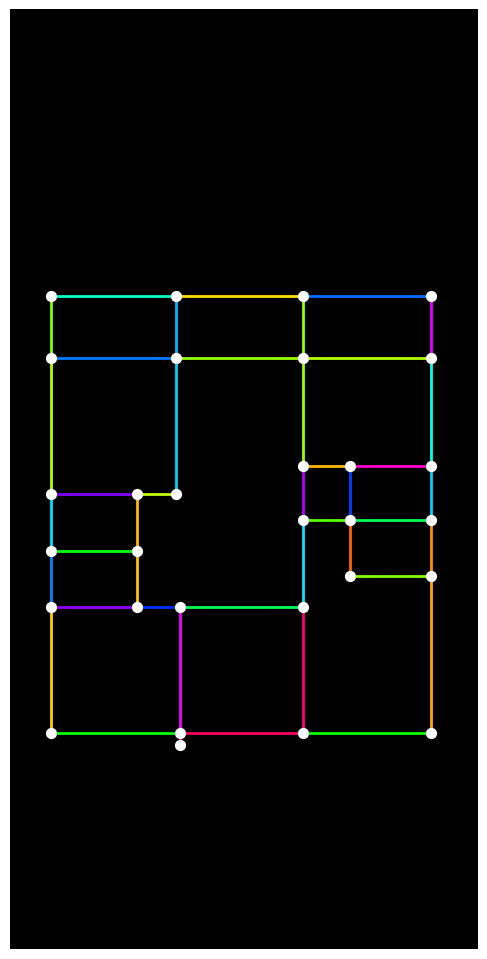

In [17]:
wall_engine._build_adjacency()
wall_engine._extend_walls_and_clean_up(max_iterations=3)
display(
wall_engine.visualize(show_node_labels=False, 
                    show_wall_labels=False)
)

### Step 1.8 Cleaning the Graph, Removing Non-Room Structures and Merge Redundant Nodes and Edges

#### Here a series of operations are performed for the clean up of the graph. Any duplicate edges are removed, nodes are realigned to ensure orthogonality, removing any non-room structures and finally reseting the graph cache

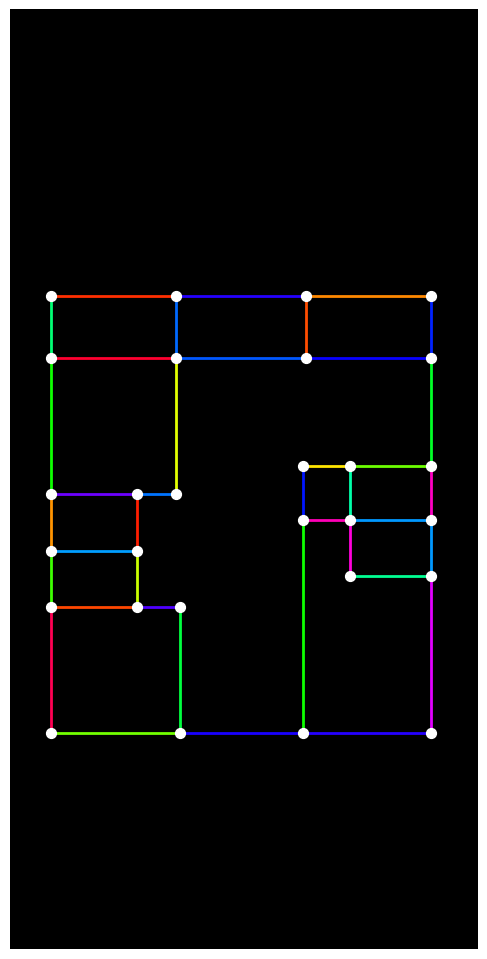

In [17]:
# Final cleanup
wall_engine._deduplicate_edges()
wall_engine._realign_nodes()

# Remove non-room structures and clean up
wall_engine._remove_non_room_structures()
wall_engine._reset_graph_cache()
while True:
    wall_engine._build_adjacency()
    num_edges_before = len(wall_engine.edges)
    wall_engine.nodes, wall_engine.edges = wall_engine._merge_redundant()
    if len(wall_engine.edges) >= num_edges_before:
        break
wall_engine._reset_graph_cache()
display(
wall_engine.visualize(show_node_labels=False, 
                    show_wall_labels=False)
)

### Step 1.9 Normalize the graph and Classify the walls into external and internal walls

#### After the normalizing the graph, the walls are classified into external or internal walls by their position in the graph

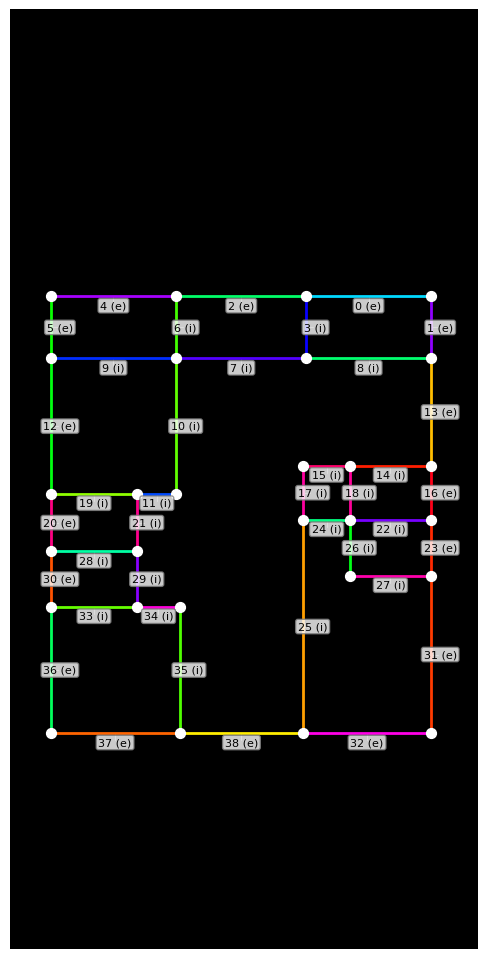

In [18]:
# NEW: Final coordinate normalization after all processing
min_x, min_y = wall_engine._compute_min_coords()

if min_x < 0 or min_y < 0:
    wall_engine._normalize_nodes(min_x, min_y)

# Rebuild and classify
wall_engine._build_adjacency()
wall_engine._classify_edges()
display(
wall_engine.visualize(show_node_labels=False, 
                    show_wall_labels=True)
)

### Step 2 Doors And Windows

In [19]:
# Efficient mask creation using numpy
masks = np.zeros((2, *seg_output[0][0].shape), dtype=np.uint8)
masks[0] = (seg_output[0][0] == 2)  # doors
masks[1] = (seg_output[0][0] == 3)  # windows
doors_mask, windows_mask = masks[0], masks[1]
if np.any(masks):
    opening_engine = OpeningDetectorEngine()

### Step 2.1 Creating a wall mask using the wall graph

In [20]:
opening_engine.create_wall_mask(wall_engine.nodes,
        wall_engine.edges, doors_mask.shape)

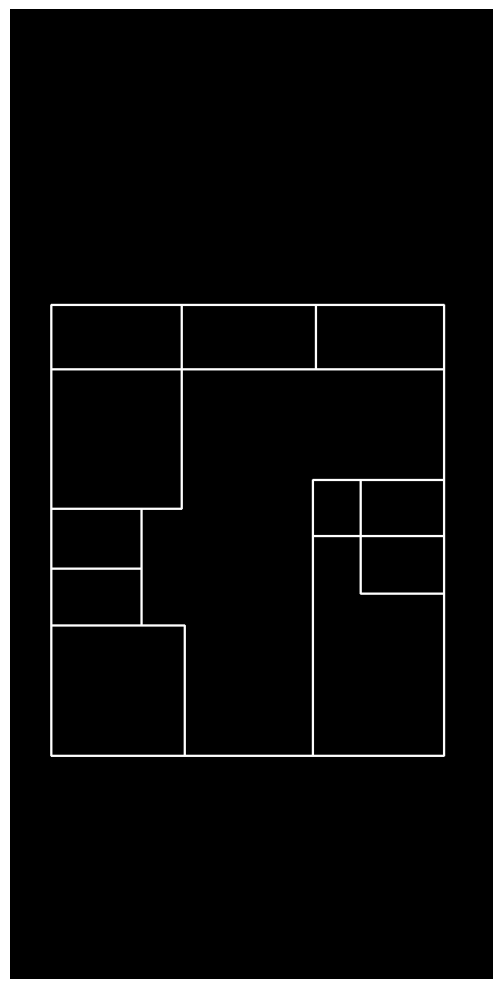

In [21]:
display(visualize_and_save_binary_image(opening_engine.wall_mask, save_path=None))

### Step 2.2 Filtering the doors
#### The following ensures that only the parts of the input mask that are close to the walls are kept, effectively filtering out regions that are too far from any wall.

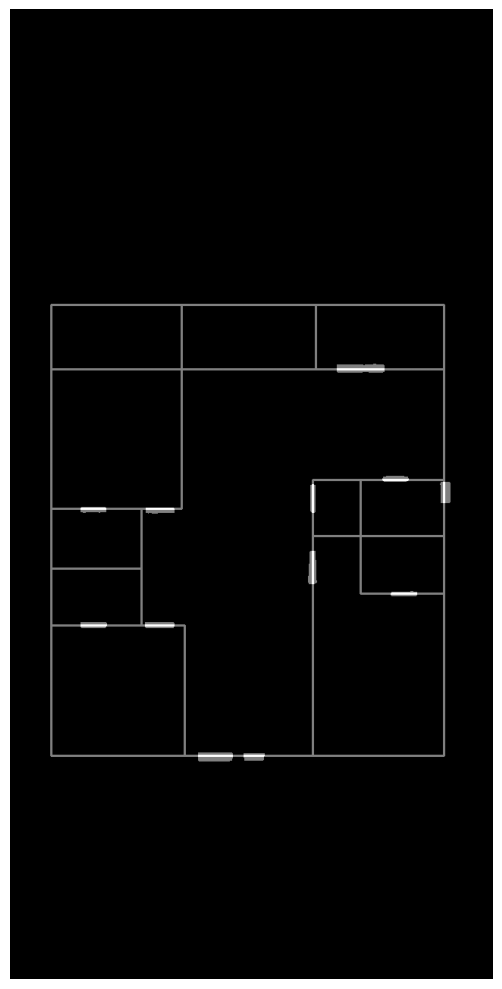

In [22]:
filtered_doors = opening_engine.filter_by_walls(doors_mask)
display(visualize_and_save_binary_image(filtered_doors + opening_engine.wall_mask, save_path=None))

### Step 2.3 Filtering the windows by the same logic as above

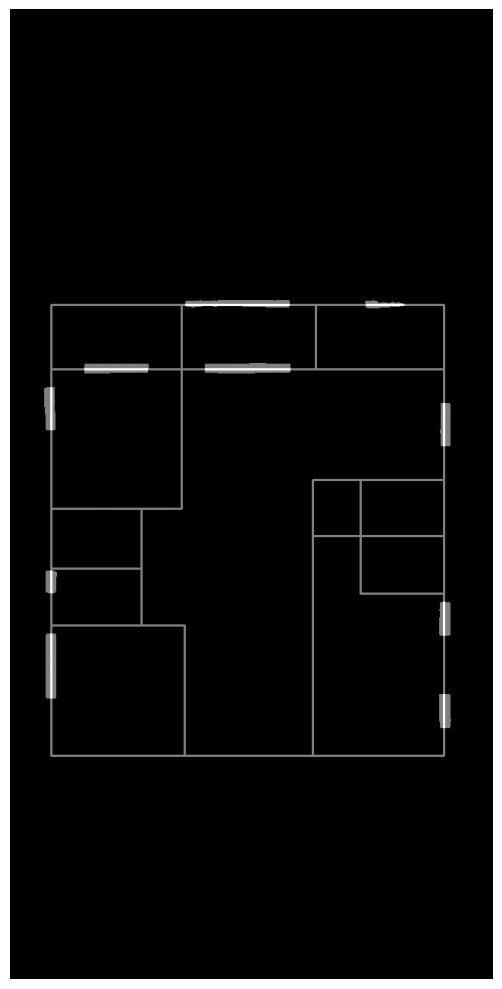

In [23]:
filtered_windows = opening_engine.filter_by_walls(windows_mask)
display(visualize_and_save_binary_image(filtered_windows + opening_engine.wall_mask, save_path=None))

### Step 2.4 Using filtered Mask for doors and windows to compute BBox and Center for Doors and Windows

#### Using connected components all the doors and windows are identified with their centroids and bounding boxes. These are then filterd based on their aspect ratio and solidity.

In [24]:
door_components = opening_engine.process_components(filtered_doors, 'Door')
window_components = opening_engine.process_components(filtered_windows, 'Window')

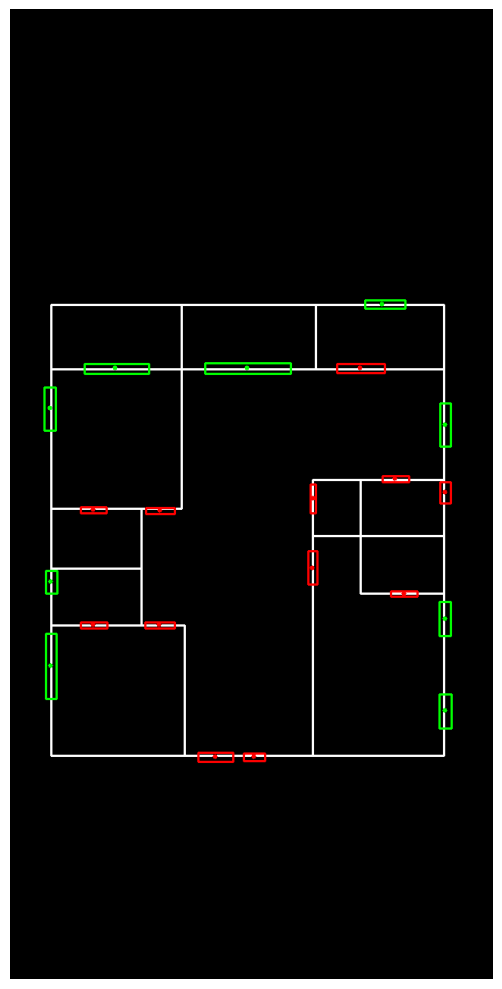

In [25]:
components_image = opening_engine.visualize(opening_engine.wall_mask,
                                            door_components, 
                                            window_components,)
display(visualize_and_save_binary_image(components_image, save_path=None))

### Step 3 Process Rooms

In [26]:
room_engine = PlanSegmentorEngine(wall_engine)
print('Room engine output:', room_engine)
detected_rooms = room_engine.detect_rooms()
print('Detected rooms:', detected_rooms)

Room engine output: <core.plan_segmentation_engine.PlanSegmentorEngine object at 0x7fd593b32450>
Detected rooms: [[5], [3], [3], [11], [2, 4], [12], [17], [4], [0, 2], [0], [31], [7, 9]]


### Step 3.1 Draw Walls
#### Using the graph's edges and nodes to draw the walls.

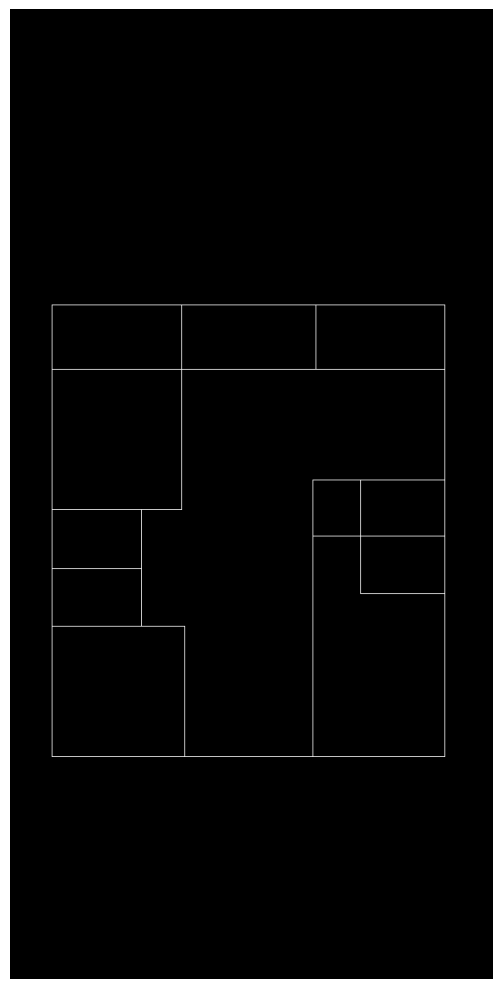

In [27]:
walls = room_engine._draw_walls()
display(visualize_and_save_binary_image(walls, save_path=None))

### Step 3.2 Identify interior regions and labelling different rooms
#### Here, flood-fill algorithm to identify and label the interior regions of a floor plan 

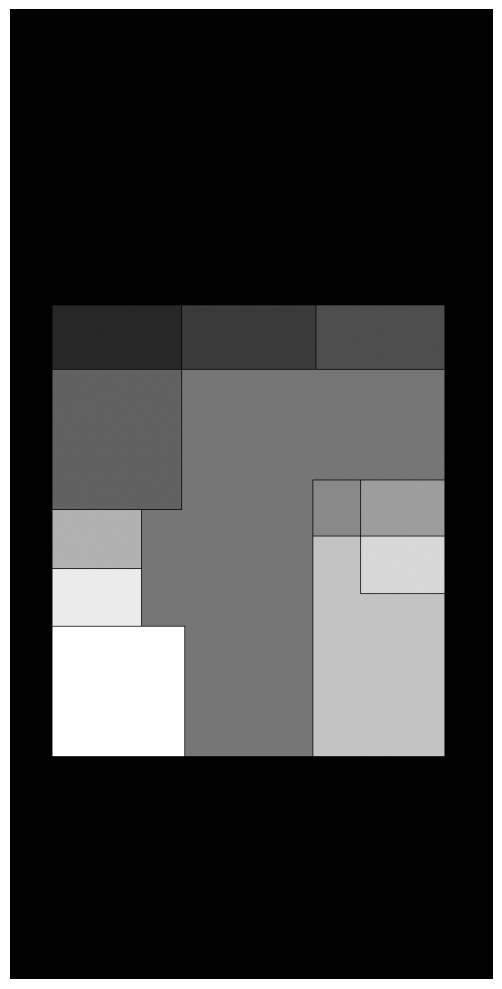

In [28]:
inside_mask, labeled, num_labels = room_engine._get_inside_walls_mask_and_labels(walls)
room_engine.raster_rooms = -1 * np.ones((room_engine.h, room_engine.w), dtype=int)
room_engine.raster_rooms[inside_mask] = labeled[inside_mask]

display(visualize_and_save_binary_image(room_engine.raster_rooms, save_path=None))

### Step 3.3 Extracting room properties and walls associated with each room

#### Here, properties of room like area, centroid and boundary points are computed. The walls associated with each room are identified by analyzing the connections between nodes and edges in the wall graph.

/home/ubuntu/repos/flp_test_work_2026/dc_ai_service/core/plan_segmentation_engine.py:247: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(n_plots,1,figsize=figsize)


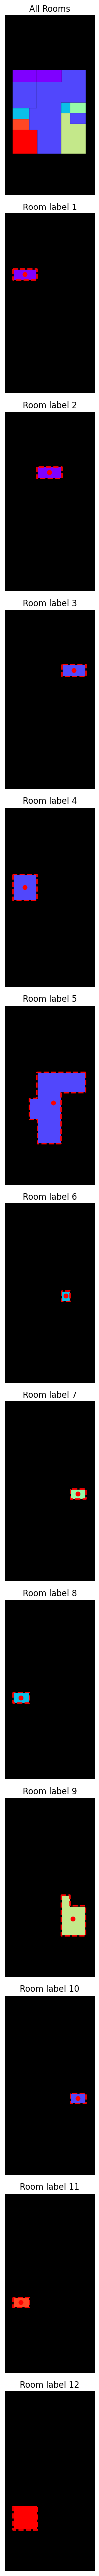

In [29]:
room_engine._extract_room_properties(labeled, num_labels)
room_engine.room_walls = room_engine._get_room_walls()
display(room_engine.visualize(individual_rooms=True))

### Step 4: Room classification

In [30]:
room_classifier = RoomClassifierEngine(room_engine, ocr_output, yolo_output)

### Step 4.1 Extract words 

#### Here based on position and confidence word predictions are filtered.

In [31]:
words_data = room_classifier._extract_words()
for word in words_data:
    print(word)


{'word': 'Jaswhitha', 'coords': (np.float64(171.625), np.float64(10.625))}
{'word': 'Luxor_Brochure.pdf', 'coords': (np.float64(315.375), np.float64(11.25))}
{'word': '-', 'coords': (np.float64(410.375), np.float64(11.875))}
{'word': 'Read-only', 'coords': (np.float64(465.375), np.float64(11.875))}
{'word': 'KN', 'coords': (np.float64(426.0), np.float64(58.125))}
{'word': 'R7', 'coords': (np.float64(426.0), np.float64(75.625))}
{'word': 'WEST', 'coords': (np.float64(92.87496185302734), np.float64(125.62499046325684))}
{'word': 'WEST', 'coords': (np.float64(184.12496185302734), np.float64(125.62499046325684))}
{'word': 'EAST', 'coords': (np.float64(277.25), np.float64(125.625))}
{'word': 'EAST', 'coords': (np.float64(368.5), np.float64(125.625))}
{'word': 'EAST', 'coords': (np.float64(459.75), np.float64(125.625))}
{'word': 'EAST', 'coords': (np.float64(551.0), np.float64(125.625))}
{'word': 'EA', 'coords': (np.float64(624.0), np.float64(125.625))}
{'word': 'ft.', 'coords': (np.float64(

### Step 4.2 Process rooms
#### Using the objects identified from YOLO and filtered words, initial room classification is performed

In [32]:
room_classifier.room_engine_results

In [33]:
results, debug_results = room_classifier._process_rooms(words_data, debug=True)


Analyzing text: '.0.9WideBalcony'
Similarity between '.0.9WideBalcony' and 'bathroom': 0.348
Similarity between '.0.9WideBalcony' and 'toilet': 0.381
Similarity between '.0.9WideBalcony' and 'bath': 0.222
Similarity between '.0.9WideBalcony' and 'wc': 0.250
Similarity between '.0.9WideBalcony' and 'tolet': 0.300
Similarity between '.0.9WideBalcony' and 'commontoilet': 0.296
Similarity between '.0.9WideBalcony' and 'common toilet': 0.296
Similarity between '.0.9WideBalcony' and 'washroom': 0.348
Similarity between '.0.9WideBalcony' and 'powder room': 0.462
Similarity between '.0.9WideBalcony' and 'restroom': 0.333
Similarity between '.0.9WideBalcony' and 'lavatory': 0.364
Similarity between '.0.9WideBalcony' and 'bedroom': 0.348
Similarity between '.0.9WideBalcony' and 'bed room': 0.348
Similarity between '.0.9WideBalcony' and 'bed': 0.222
Similarity between '.0.9WideBalcony' and 'master bedroom': 0.286
Similarity between '.0.9WideBalcony' and 'master bed': 0.250
Similarity between '.0

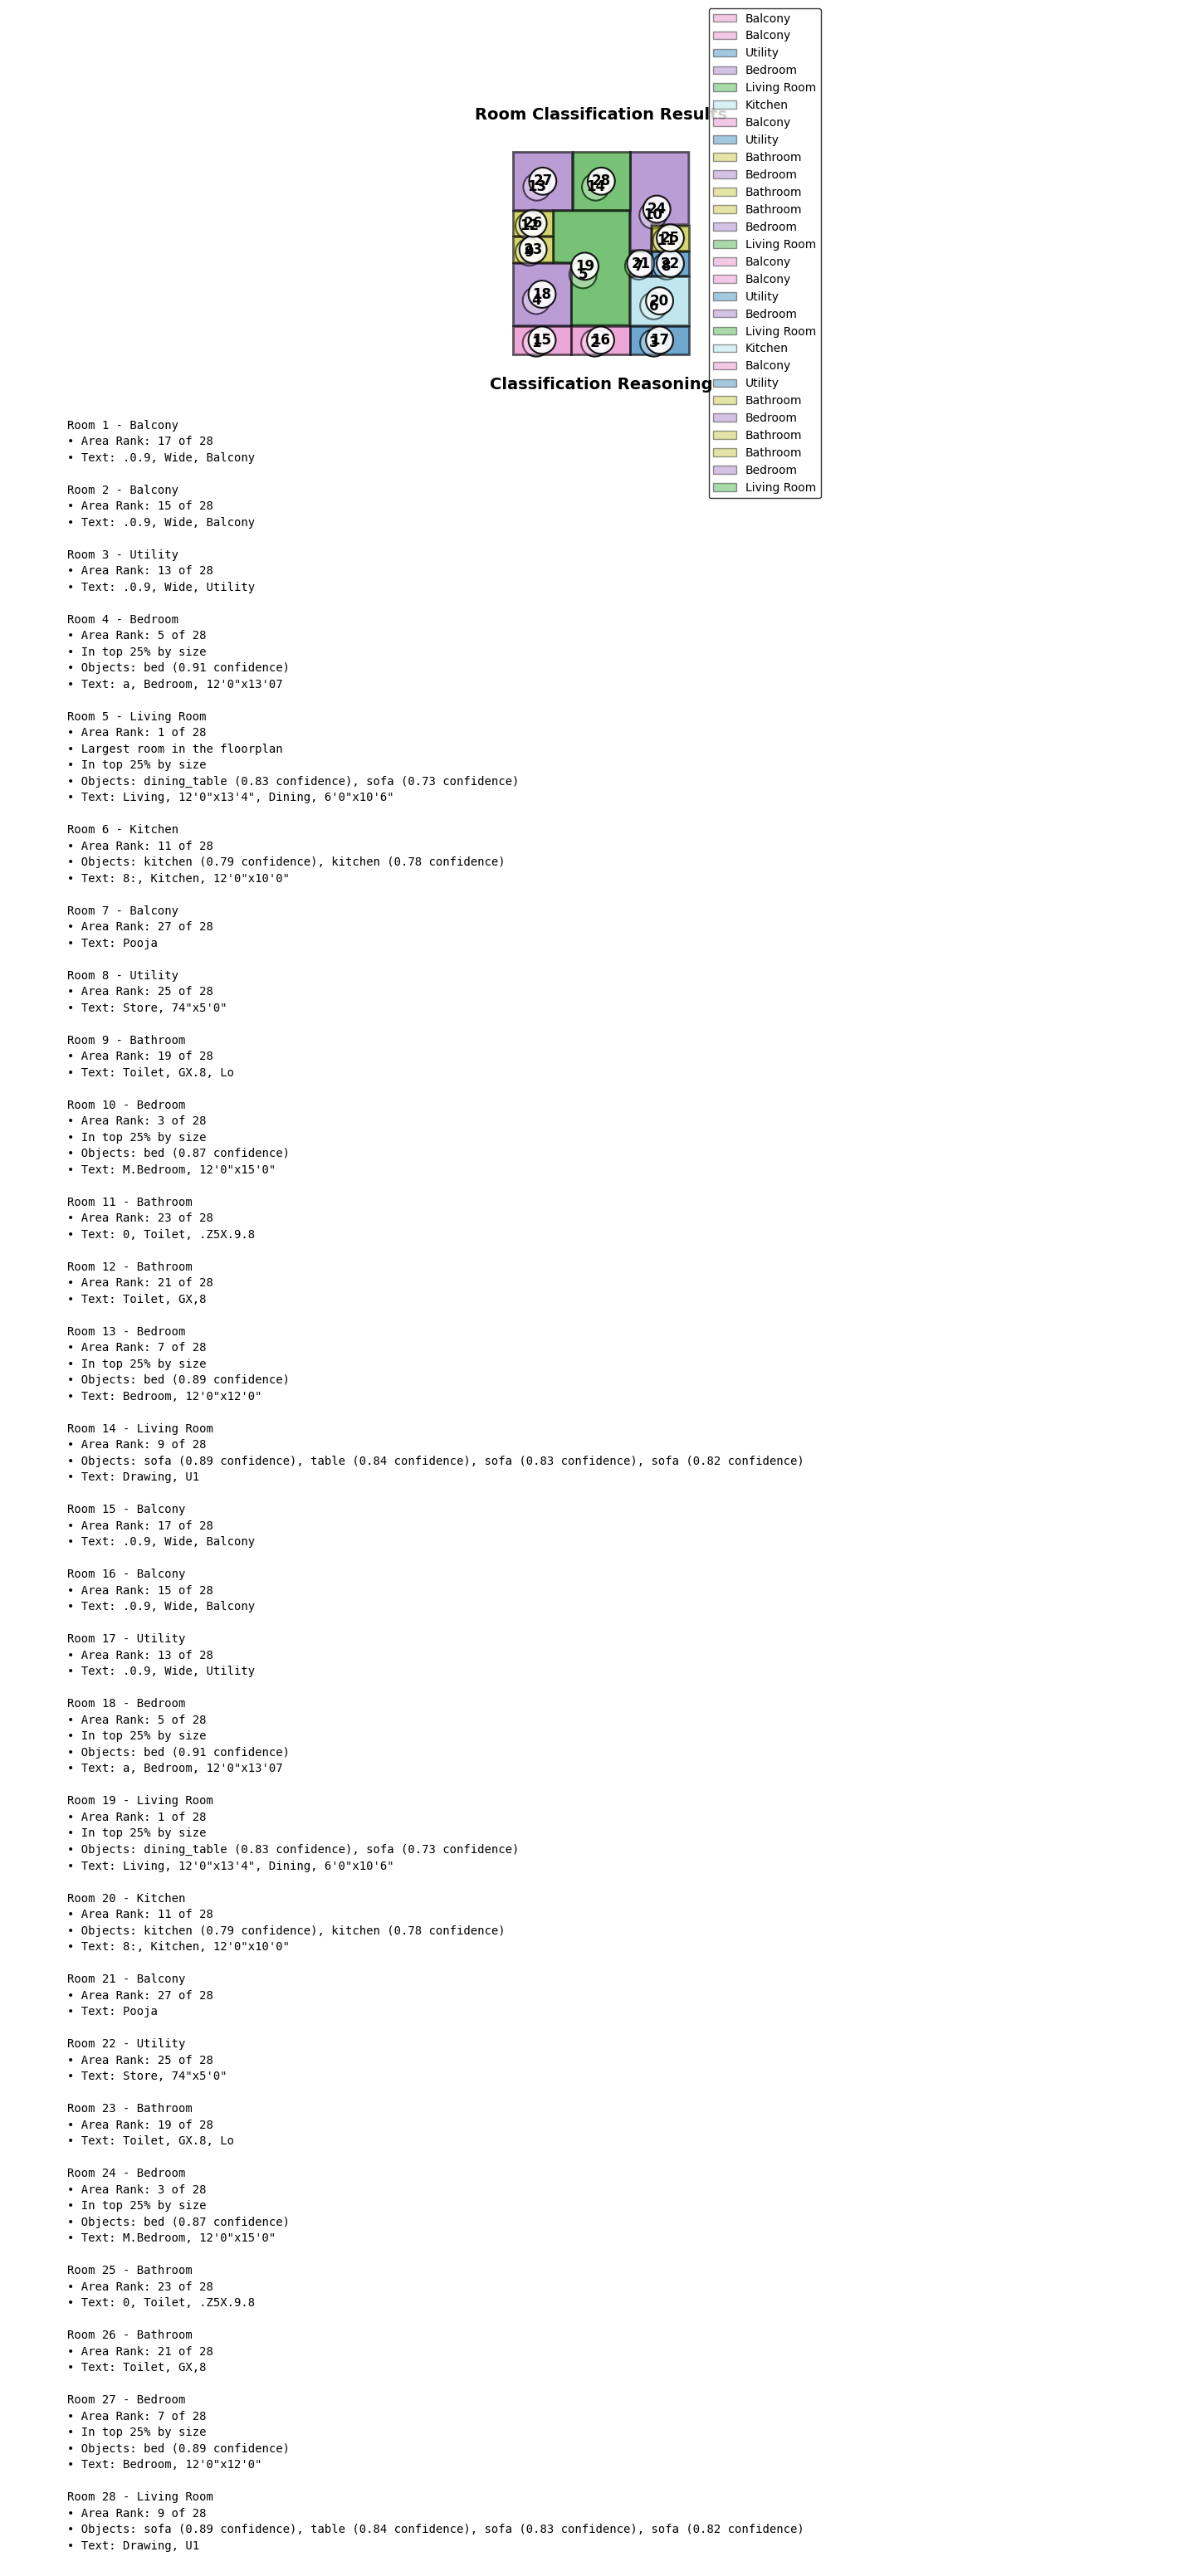

In [35]:
initial_room_classifcation_visual = room_classifier._visualize_classification(
                                                                    results=results,
                                                                    debug_results=debug_results,
                                                                    floorplan_dims=(2000, 2000)
                                                                    )
display(initial_room_classifcation_visual)

### Step 4.3 Apply Sanity Checks
#### Applying size based rules to ensure the classifications are consistent with expected room sizes.

In [34]:
# Apply size-based sanity checks
results = room_classifier._apply_size_sanity_checks(results, debug_results)

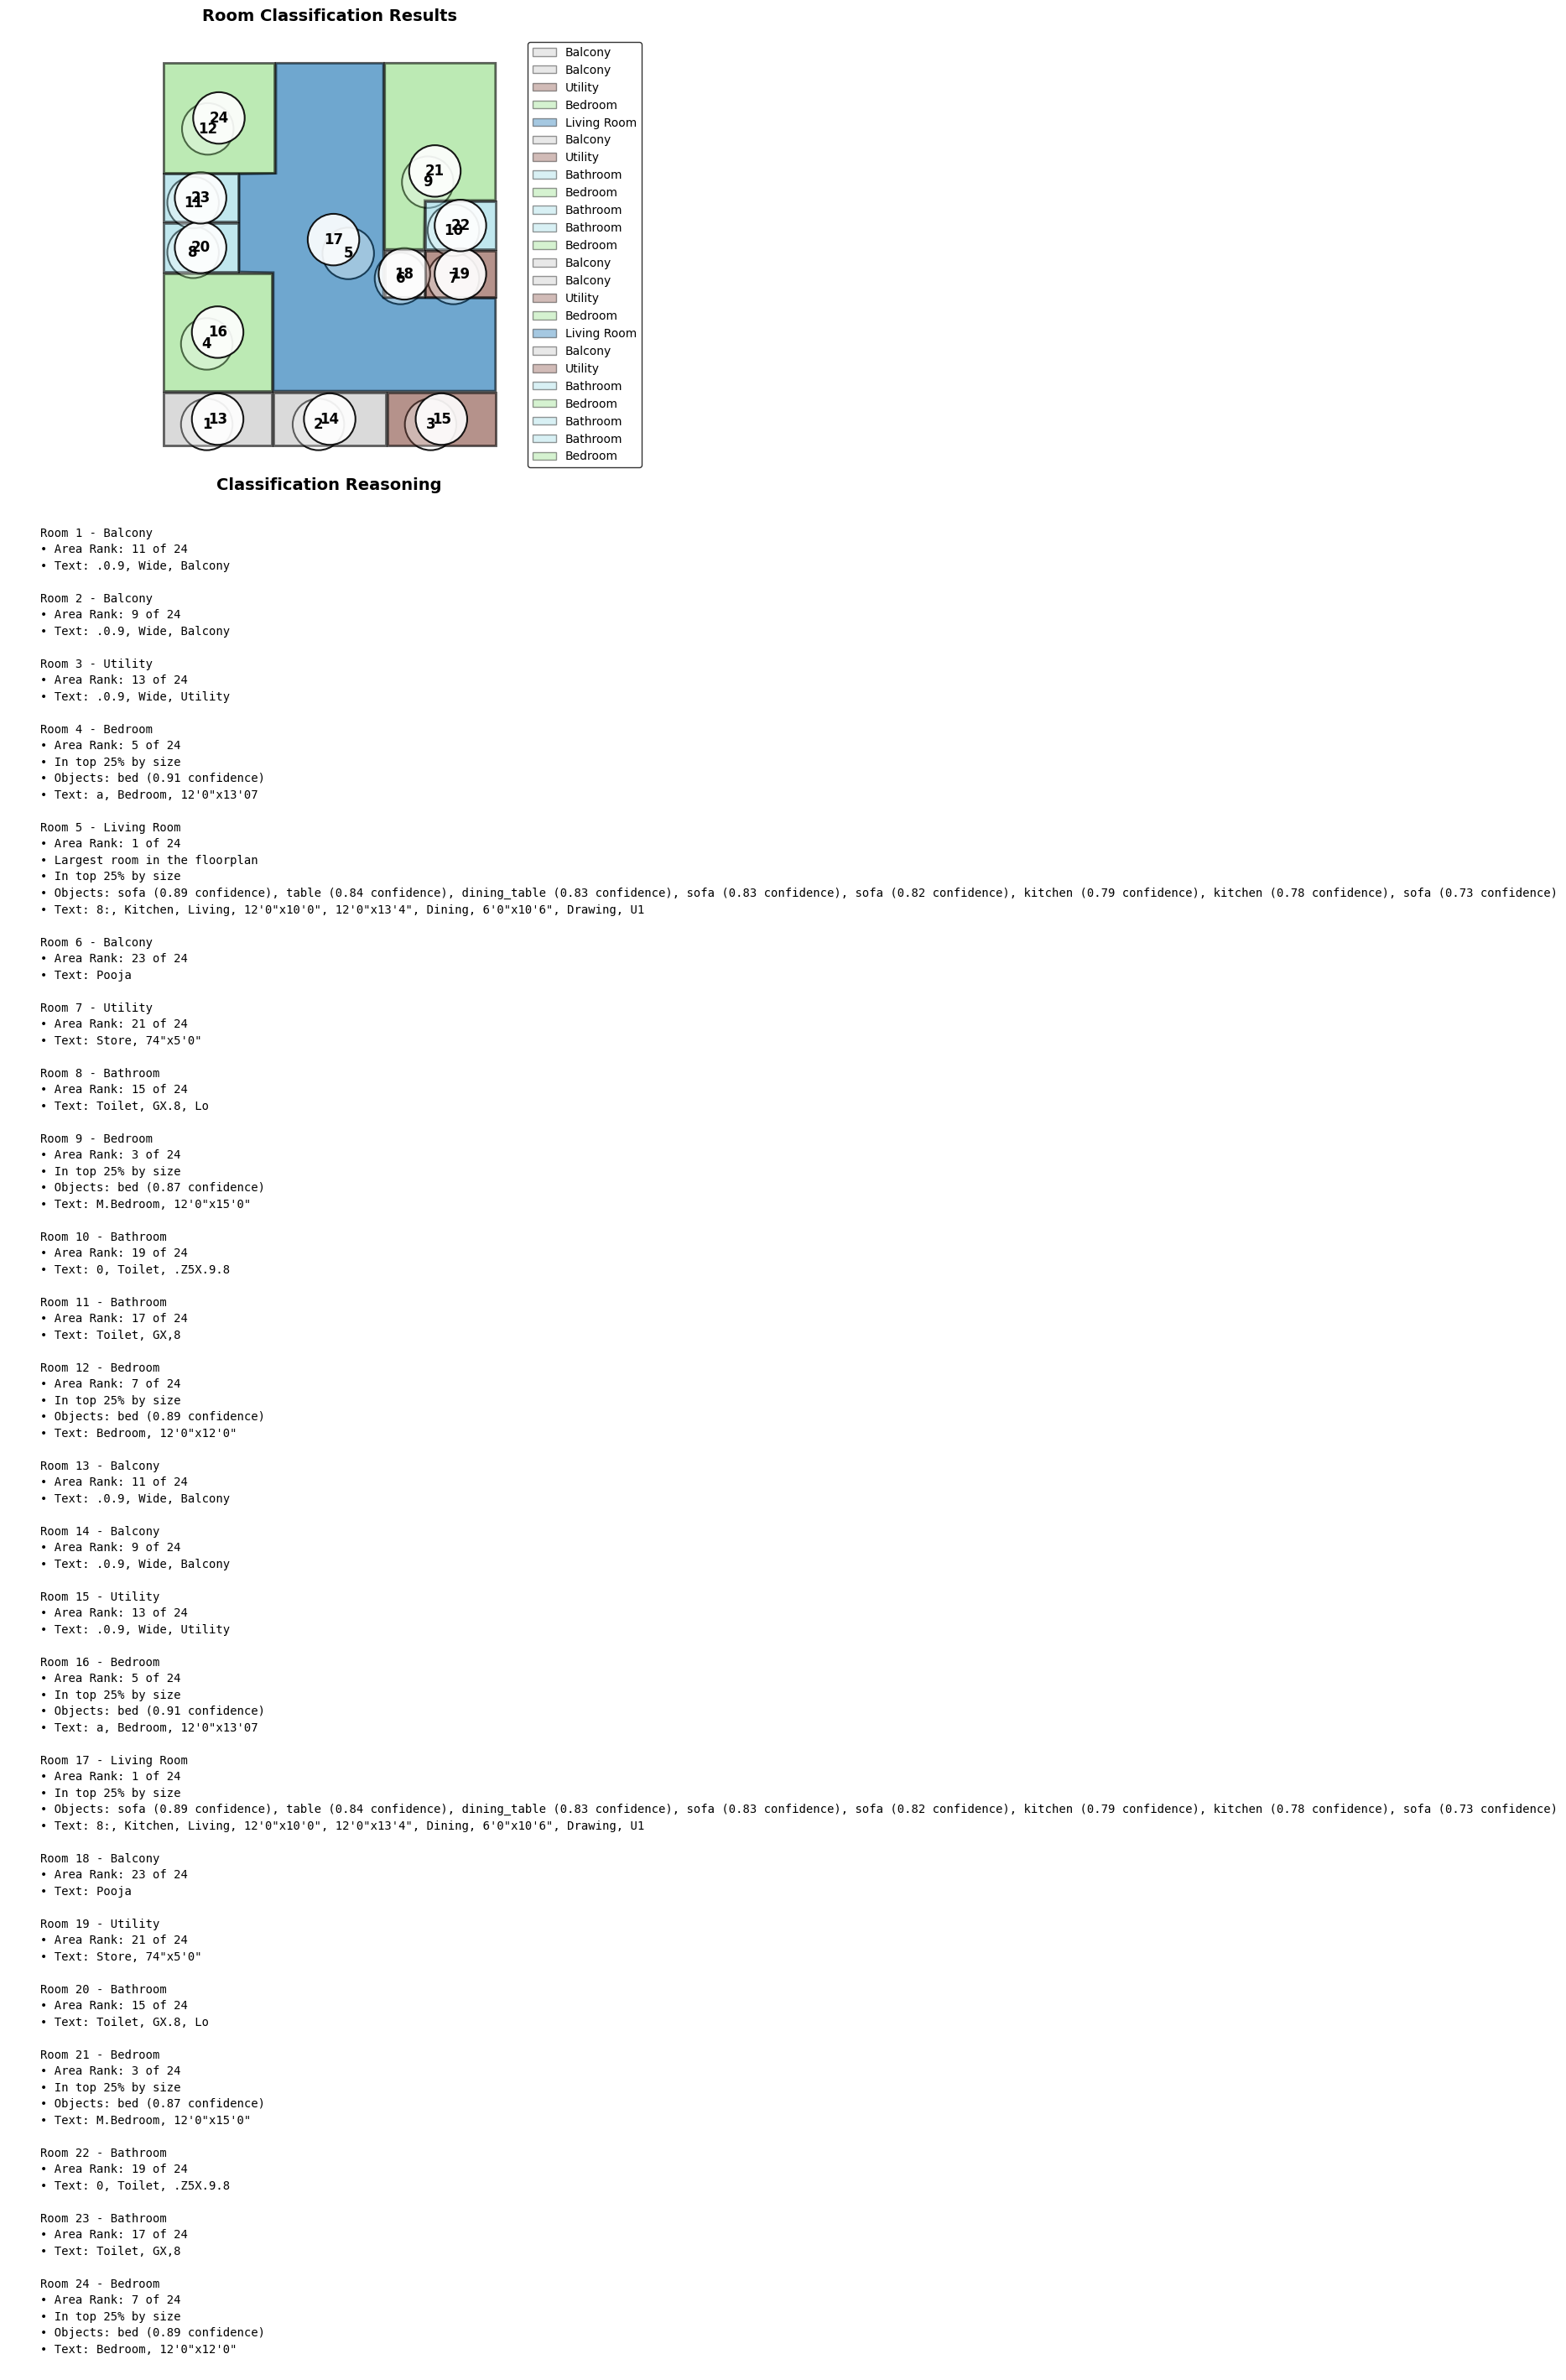

In [35]:
sanity_checked_room_classifcation_visual = room_classifier._visualize_classification(
                                                                    results=results,
                                                                    debug_results=debug_results,
                                                                    floorplan_dims=(2000, 2000)
                                                                    )
display(sanity_checked_room_classifcation_visual)

### Step 4.4 Ensure Room Distribution
#### Using heuristics to ensure a balance and plausibile distribution of room types.

In [36]:
# Apply initial distribution adjustments
classified_rooms = room_classifier._ensure_room_distribution(results, debug_results, debug=True)

# room_classifier._print_debug_info(results, debug_results)
    
room_classifcation_visual = room_classifier._visualize_classification(
                                                                    results=results,
                                                                    debug_results=debug_results,
                                                                    floorplan_dims=(2000, 2000)
                                                                    )

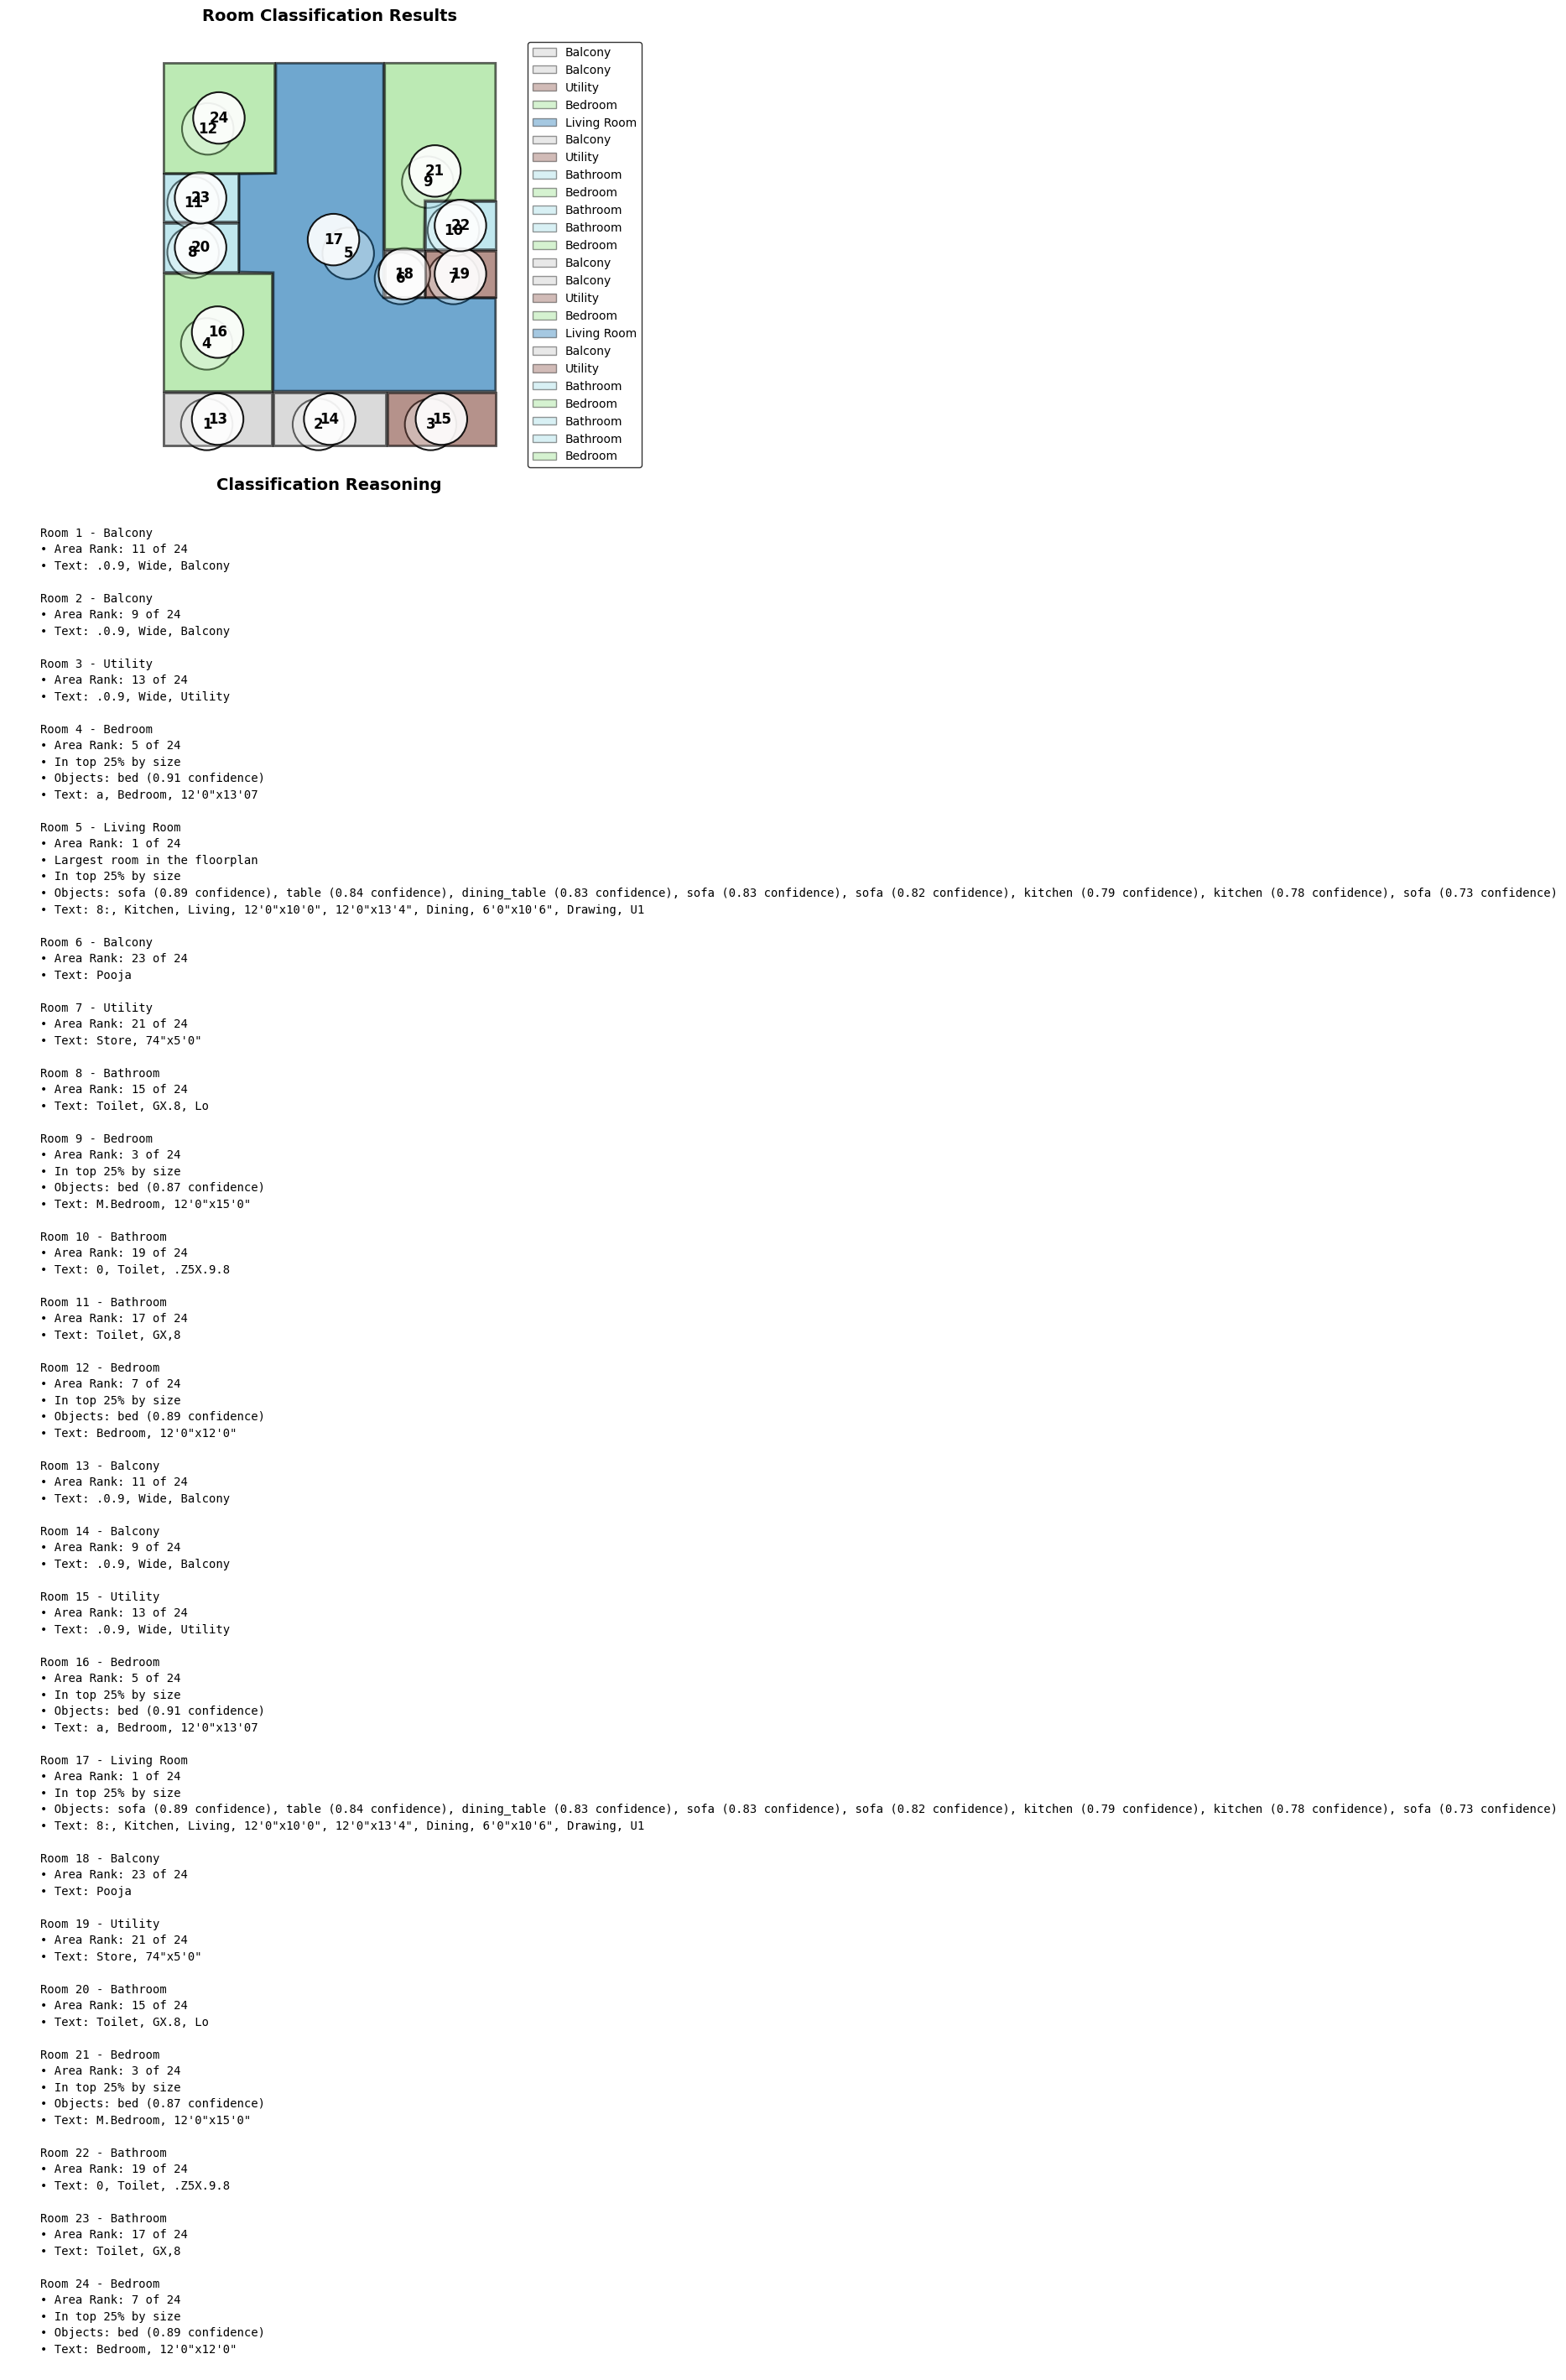

In [37]:
display(room_classifcation_visual)

In [38]:
# Efficient room processing
rooms = []
# Process corners (pre-allocate dictionary)
corners = populate_corners(wall_engine)
walls, wall_uuid_lookup = populate_walls(wall_engine, corners)

In [39]:
# Process rooms in parallel
with ThreadPoolExecutor() as executor:
    rooms = list(filter(None, executor.map(populate_room_info, 
                                            repeat(room_engine.room_walls),                                         
                                            enumerate(classified_rooms),
                                            repeat(walls))))

### Step 5: Process furniture

### Step 5.1 Assigning furniture to rooms based on their position and resolves any collisions between furniture items

In [40]:
# Process furniture - use numpy for vectorized operations where possible
valid_furniture = {'bed', 'toilet', 'kitchen', 'sofa', 'dining_table'}

furnitures = process_furniture_with_corners(yolo_output, rooms, walls, valid_furniture)

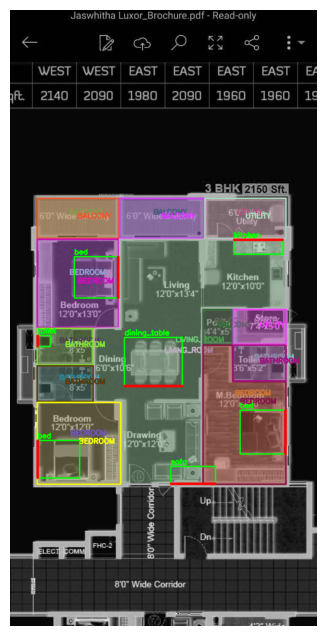

In [41]:
display(visualize_rooms_and_furniture(original_image, rooms, furnitures))

### Step 5.2 Ensuring placement rules

In [42]:
furnitures = filter_furniture_by_room_type(rooms, furnitures)

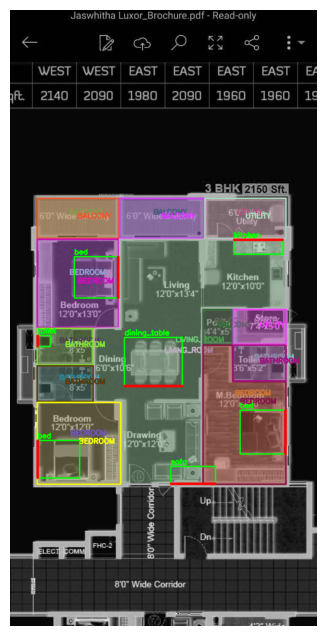

In [43]:
display(visualize_rooms_and_furniture(original_image, rooms, furnitures))

In [44]:
balcony_walls = find_balcony_walls(wall_engine, rooms, wall_uuid_lookup, epsilon=5)

In [45]:
from utils import visualize_walls

In [46]:
walls_fig = visualize_walls(walls, figsize=(12, 6))

### Wall graph before identifying balcony walls

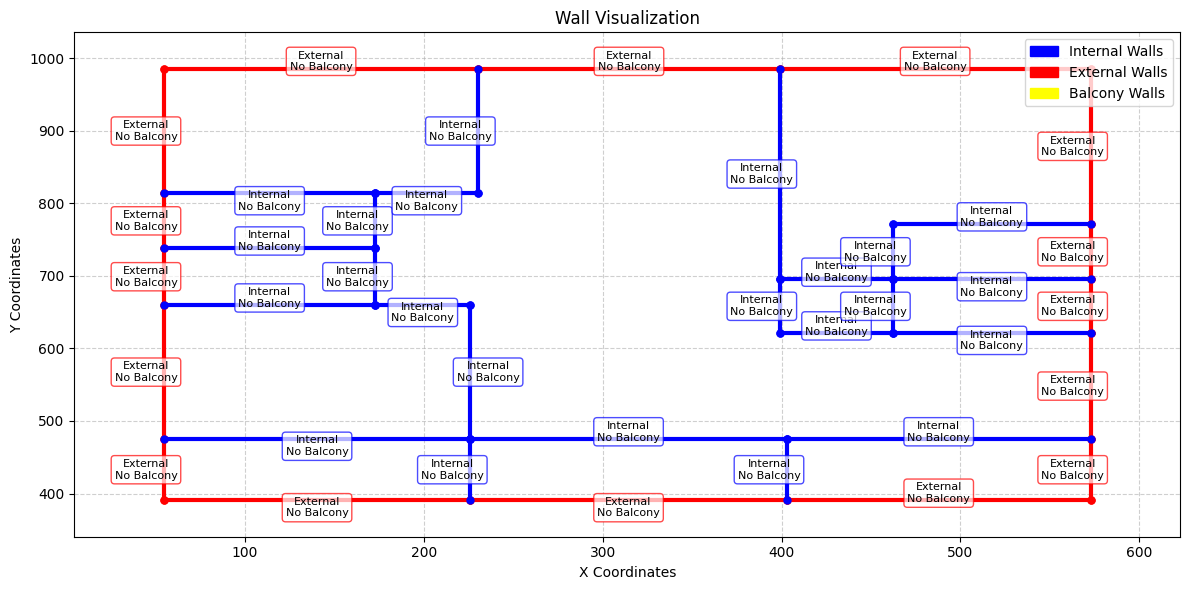

In [47]:
walls_fig

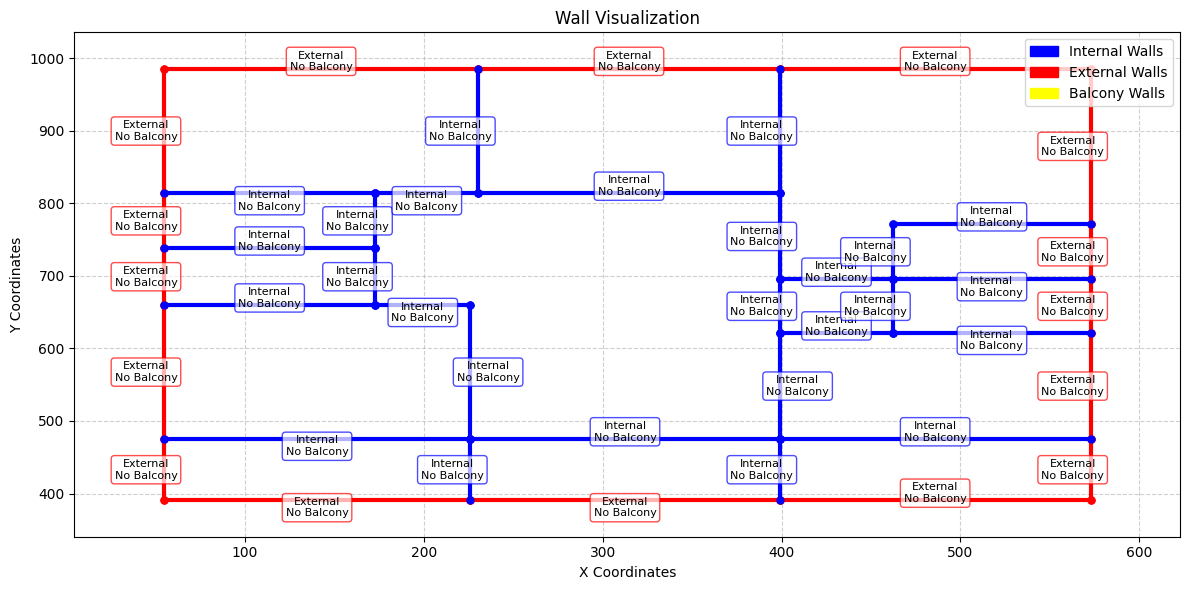

In [56]:
balcony_walls
display(walls_fig)

Updated walls with balcony adjustments: [{'uuid': '9d54be71-1c4e-4252-b60c-f8944f9cb02a', 'corner1': 'dfe9ada6-c9c0-4b48-8cf4-bad44d45060e', 'corner2': 'aad5c8e3-6b8a-4073-9a6f-61f3ad29f7da', 'internal': False, 'pixels': [[403.0, 390.5], [572.75, 390.5]], 'balcony': False}, {'uuid': '05e0dbcf-21e7-419c-91d8-3406bfa7b842', 'corner1': 'aad5c8e3-6b8a-4073-9a6f-61f3ad29f7da', 'corner2': '41c0de43-de86-4fb8-af34-c860ee264ce9', 'internal': False, 'pixels': [[572.75, 390.5], [572.75, 475.125]], 'balcony': False}, {'uuid': '82a7dc21-6dac-4d01-9343-5fa36d9db796', 'corner1': 'dfe9ada6-c9c0-4b48-8cf4-bad44d45060e', 'corner2': '4d43b1c7-404b-4ff5-8bf6-567b0e23ca90', 'internal': False, 'pixels': [[403.0, 390.5], [226.0, 390.5]], 'balcony': True}, {'uuid': 'f2bcf594-34f5-4c6b-bf67-00430123307c', 'corner1': '4d43b1c7-404b-4ff5-8bf6-567b0e23ca90', 'corner2': 'a057df82-e704-431f-b766-2abe00688337', 'internal': False, 'pixels': [[226.0, 390.5], [54.75, 390.5]], 'balcony': True}, {'uuid': 'bb8bb590-44f5-

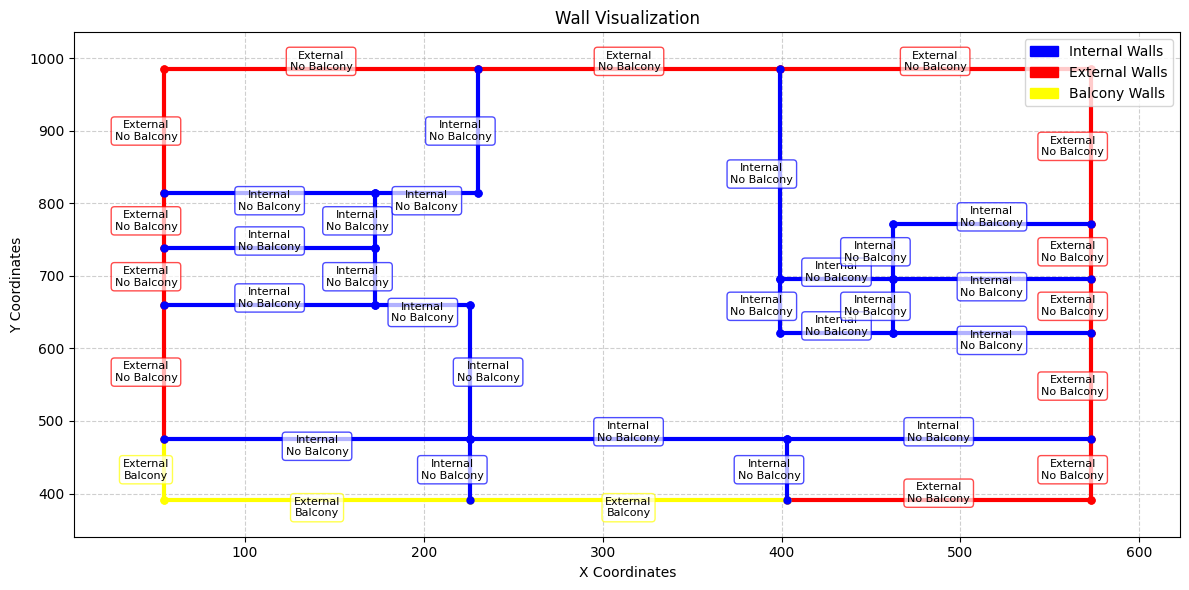

In [48]:
walls = update_balcony_walls(walls, balcony_walls)
print("Updated walls with balcony adjustments:", walls)
display(visualize_walls(walls, figsize=(12, 6)))

Walls with balcony adjustments: Figure(1200x600)


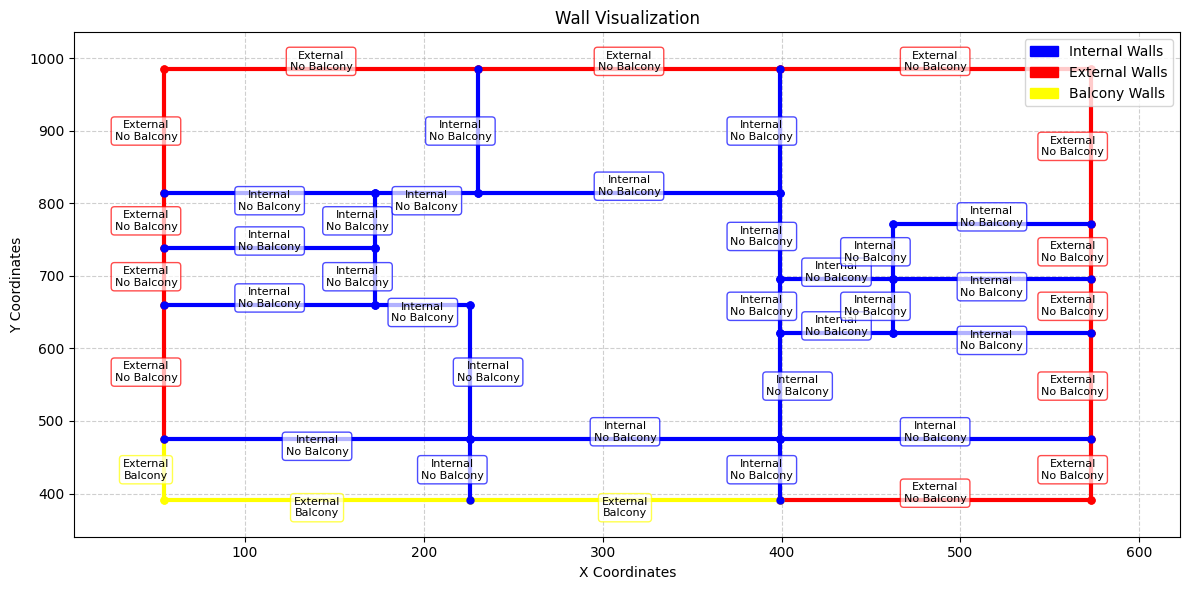

In [54]:
walls_with_balcony_fig = visualize_walls(walls, figsize=(12, 6))
print("Walls with balcony adjustments:", walls_with_balcony_fig)
display(walls_with_balcony_fig)

### Wall graph after identifying balcony walls

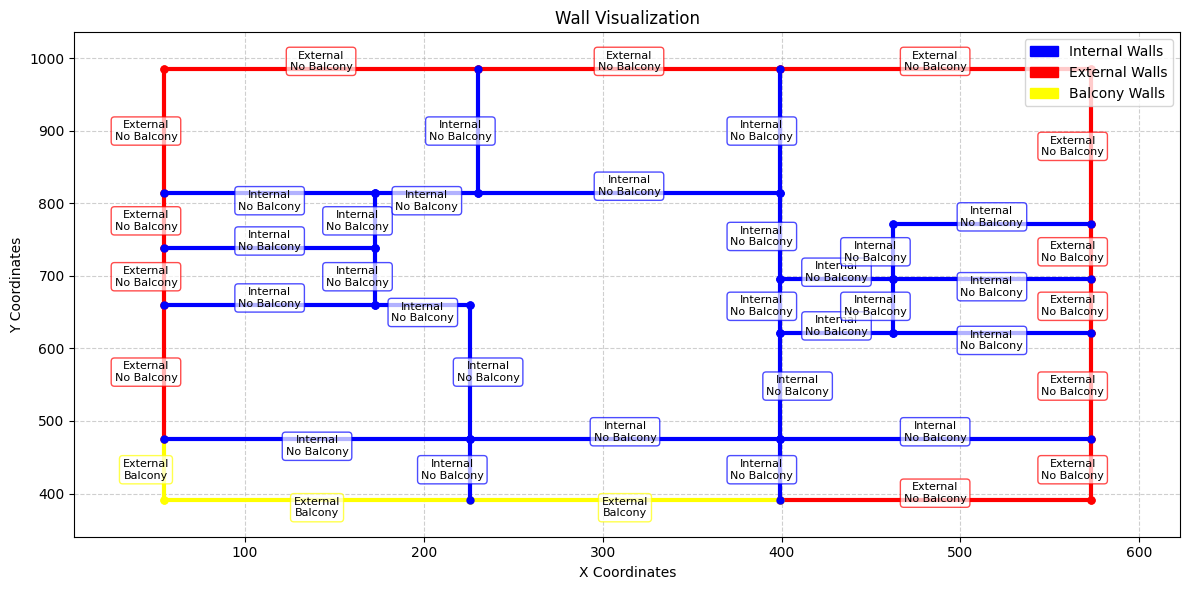

In [57]:
walls_with_balcony_fig

# New Script

## Process images in a batch

In [1]:
import sys
import uuid
import cv2
import os
from pathlib import Path
from itertools import repeat
from IPython.display import display
from typing import Dict, List, Set, Tuple, Any
from concurrent.futures import ThreadPoolExecutor

import numpy as np
from ultralytics import YOLO
from matplotlib import pyplot as plt
from shapely import Polygon, prepared

from skimage.morphology import skeletonize
#%matplotlib inline

sys.path.append('/home/ubuntu/repos/dc_ai_service')

#from flp_test_work_2026.dc_ai_service.readme_may26 import SEG_MODEL_PATH
from utils import read_image_adjust_dimensions, visualize_rooms_and_furniture, visualize_and_save_binary_image, \
visualize_yolo_detections
from model_loader import ModelLoader
from app import run_segmentation, run_ocr, run_yolo
from core.wall_engine import WallDetectorEngine
from core.opening_detector_engine import OpeningDetectorEngine
from core.plan_segmentation_engine import PlanSegmentorEngine
from core.room_classifier_engine import RoomClassifierEngine
from postprocess import process_walls_parallel, process_furniture_with_corners, calculate_scale_factor,\
filter_furniture_by_room_type, calculate_room_areas, populate_room_info, populate_walls, process_room_polygon,\
populate_corners, find_balcony_walls, update_balcony_walls


WARNING ⚠️ Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at '/home/ubuntu/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/home/ubuntu/miniconda/envs/floorplan/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-12 10:56:58,079 - app - INFO - Initializing ModelLoader...
2026-05-12 10:56:58,899 - root - INFO - Using downloaded & verified file: /home/ubuntu/.cache/doctr/models/fast_base-688a8b34.pt
2026-05-12 10:57:01,410 - root - INFO - Using downloaded & verified file: /home/ubuntu/.cache/doctr/models/crnn_vgg16_bn-0417f351.pt
2026-05-12 10:57:01,539 - root - INFO - Using downloaded & verified file: /home/ubuntu/.cache/doctr/models/mobilenet_v3_small_crop_orientation-f0847a18.pt
2026-05-12 10:57:01,636 - root - INFO - Using downloaded & verified file: /home/ubuntu/.cache/doctr/models/mobilenet_v3_small_page_orientation-8e60325c.pt
2026-05-12 10:57:36,815 - app - INFO - ModelLoader initialized successfully


In [2]:
# =========================================================
# PATH SETUP
# =========================================================

BASE_DIR = Path.cwd()
IMG_DIR = BASE_DIR / "test_images" / "test_imgs"

if not IMG_DIR.exists():
    IMG_DIR = BASE_DIR / "dc_ai_service" / "test_images" / "test_imgs"

OUTPUT_DIR = Path("multi_image_outputs_2026")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Resolved IMG_DIR: {IMG_DIR}")

# =========================================================
# GET ALL IMAGES
# =========================================================

image_files = [
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print(f"Total images found: {len(image_files)}")

Resolved IMG_DIR: /home/ubuntu/repos/flp_test_work_2026/dc_ai_service/test_images/test_imgs
Total images found: 11


In [ ]:
#model loading path

SEG_MODEL_PATH = '/home/ubuntu/repos/dc_ai_service/checkpoints/ckpt_fold_all'
YOLO_MODEL_PATH = '/home/ubuntu/repos/dc_ai_service/checkpoints/yolo.pt'

SEG_MODEL_DIR = "/home/ubuntu/repos/flp_test_work_2026/dc_ai_service/checkpoints/ckpt_fold_all"
SEG_CHECKPOINT = "checkpoint_best.pth"
print(f"Segmentation model directory: {SEG_MODEL_DIR}")
print(f"Segmentation checkpoint: {SEG_CHECKPOINT}")

YOLO_MODEL_PATH = "/home/ubuntu/repos/flp_test_work_2026/dc_ai_service/checkpoints/yolo.pt"
print(f"YOLO model path: {YOLO_MODEL_PATH}")

IMAGE_EXTENSIONS = ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]

model_loader_obj = ModelLoader()
predictor = model_loader_obj.get_predictor()
predictor.initialize_from_trained_model_folder(
            SEG_MODEL_PATH,
            use_folds=('all',),
            checkpoint_name='checkpoint_best.pth')
model_loader_obj.yolo_model = YOLO(YOLO_MODEL_PATH)

print("Models loaded successfully.")
print(f"Predictor: {predictor}")
print(f"YOLO model: {model_loader_obj.yolo_model}")

Segmentation model directory: /home/ubuntu/repos/flp_test_work_2026/dc_ai_service/checkpoints/ckpt_fold_all
Segmentation checkpoint: checkpoint_best.pth
YOLO model path: /home/ubuntu/repos/flp_test_work_2026/dc_ai_service/checkpoints/yolo.pt
Models loaded successfully.
Predictor: <nnunetv2.inference.predict_from_raw_data.nnUNetPredictor object at 0x7f3cc3cae390>
YOLO model: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, 

## input image

In [5]:
# =========================================================
# DISPLAY AND SAVE INPUT IMAGE FOR ALL IMAGES
# =========================================================

for image_file in image_files:

    # Full image path
    image_path = IMG_DIR / image_file

    print(f"\nProcessing: {image_file}")

    # Create output folder for this image
    image_name = Path(image_file).stem
    image_output_dir = OUTPUT_DIR / image_name
    image_output_dir.mkdir(parents=True, exist_ok=True)

    # Read image using your existing utility
    with open(image_path, "rb") as f:
        img_array = read_image_adjust_dimensions(f)

    print(f"Loaded image shape: {img_array.shape}")

    # Convert from (C, 1, H, W) -> (H, W, C)
    display_img = img_array.squeeze(1).transpose(1, 2, 0).astype(np.uint8)

    # Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(display_img)
    plt.axis("off")

    # Save figure
    output_path = image_output_dir / "input_image.png"
    plt.savefig(output_path, bbox_inches="tight", pad_inches=0)

    # Optional: display in notebook
    display(plt.gcf())

    # Close figure to free memory
    plt.close()

    print(f"Saved: {output_path}")


Processing: highland_3.png
Original image shape- inside utils.py: (615, 851, 4)
Loaded image shape: (4, 1, 615, 851)


<Figure size 1000x1000 with 1 Axes>

Saved: multi_image_outputs_2026/highland_3/input_image.png

Processing: lodha.jpg
Original image shape- inside utils.py: (1111, 2000, 3)
Loaded image shape: (3, 1, 1111, 2000)


<Figure size 1000x1000 with 1 Axes>

Saved: multi_image_outputs_2026/lodha/input_image.png

Processing: stairs_edgecase.jpeg
Original image shape- inside utils.py: (585, 524, 3)
Loaded image shape: (3, 1, 585, 524)


...

Saved: multi_image_outputs_2026/highland_1/input_image.png

Processing: test_floorplan.jpeg
Original image shape- inside utils.py: (403, 522, 3)
Loaded image shape: (3, 1, 403, 522)


<Figure size 1000x1000 with 1 Axes>

Saved: multi_image_outputs_2026/test_floorplan/input_image.png

Processing: highland_2.png
Original image shape- inside utils.py: (634, 856, 4)
Loaded image shape: (4, 1, 634, 856)


<Figure size 1000x1000 with 1 Axes>

Saved: multi_image_outputs_2026/highland_2/input_image.png


## save segmentation mask

In [6]:
# =========================================================
# RUN SEGMENTATION, OCR, AND YOLO FOR ALL IMAGES
# SAVE SEGMENTATION MASK TO OUTPUT DIRECTORY
# =========================================================

for image_file in image_files:

    # Full image path
    image_path = IMG_DIR / image_file

    print(f"\nProcessing: {image_file}")

    # Create output folder for this image
    image_name = Path(image_file).stem
    image_output_dir = OUTPUT_DIR / image_name
    image_output_dir.mkdir(parents=True, exist_ok=True)

    # -----------------------------------------------------
    # LOAD IMAGE
    # -----------------------------------------------------
    with open(image_path, "rb") as f:
        img_array = read_image_adjust_dimensions(f)

    print(f"Loaded image shape: {img_array.shape}")

    # -----------------------------------------------------
    # RUN MODELS
    # -----------------------------------------------------
    seg_output = run_segmentation(img_array)
    ocr_output = run_ocr(str(image_path))
    yolo_output = run_yolo(img_array)

    print("Segmentation completed.")
    print("OCR completed.")
    print("YOLO completed.")

    # -----------------------------------------------------
    # SAVE SEGMENTATION MASK
    # -----------------------------------------------------
    # In your pipeline, the segmentation mask is the first item.
    # Equivalent to what you use elsewhere:
    # seg_mask = seg_output[0][0]

    seg_mask = seg_output[0][0]

    # Save as PNG using your existing utility
    visualize_and_save_binary_image(
        seg_mask,
        save_path=str(image_output_dir / "segmentation_mask.png")
    )

    print(f"Saved segmentation mask to: {image_output_dir / 'segmentation_mask.png'}")

    # -----------------------------------------------------
    # SAVE OCR OUTPUT
    # -----------------------------------------------------
    with open(image_output_dir / "ocr_output.txt", "w") as f:
        f.write(str(ocr_output))

    # -----------------------------------------------------
    # SAVE SIMPLE MODEL SUMMARY
    # -----------------------------------------------------
    with open(image_output_dir / "model_summary.txt", "w") as f:
        f.write(f"Image: {image_file}\n")
        f.write("Segmentation: Completed\n")
        f.write("OCR: Completed\n")
        f.write("YOLO: Completed\n")

    print(f"Outputs saved to: {image_output_dir}")

2026-05-12 11:52:33,038 - app - INFO - Starting segmentation...



Processing: highland_3.png
Original image shape- inside utils.py: (615, 851, 4)
Loaded image shape: (4, 1, 615, 851)


100%|██████████| 2/2 [00:01<00:00,  1.15it/s]
2026-05-12 11:52:35,861 - app - INFO - Segmentation completed successfully
2026-05-12 11:52:35,862 - app - INFO - Starting OCR processing...
2026-05-12 11:52:41,355 - app - INFO - OCR processing completed successfully
2026-05-12 11:52:41,356 - app - INFO - Starting YOLO object detection...
2026-05-12 11:52:42,398 - app - INFO - YOLO detection completed successfully. Found 38 objects.


Segmentation completed.
OCR completed.
YOLO completed.


2026-05-12 11:52:42,748 - app - INFO - Starting segmentation...


...

Segmentation completed.
OCR completed.
YOLO completed.


2026-05-12 11:53:18,943 - app - INFO - Starting segmentation...


Saved segmentation mask to: multi_image_outputs_2026/test_floorplan/segmentation_mask.png
Outputs saved to: multi_image_outputs_2026/test_floorplan

Processing: highland_2.png
Original image shape- inside utils.py: (634, 856, 4)
Loaded image shape: (4, 1, 634, 856)


100%|██████████| 2/2 [00:00<00:00, 10.64it/s]
2026-05-12 11:53:19,425 - app - INFO - Segmentation completed successfully
2026-05-12 11:53:19,426 - app - INFO - Starting OCR processing...
2026-05-12 11:53:22,408 - app - INFO - OCR processing completed successfully
2026-05-12 11:53:22,408 - app - INFO - Starting YOLO object detection...
2026-05-12 11:53:22,426 - app - INFO - YOLO detection completed successfully. Found 49 objects.


Segmentation completed.
OCR completed.
YOLO completed.
Saved segmentation mask to: multi_image_outputs_2026/highland_2/segmentation_mask.png
Outputs saved to: multi_image_outputs_2026/highland_2


In [7]:
# =========================================================
# RUN SEGMENTATION, OCR, AND YOLO FOR ALL IMAGES
# SAVE SEGMENTATION MASK TO OUTPUT DIRECTORY
# =========================================================

for image_file in image_files:

    # Full image path
    image_path = IMG_DIR / image_file

    print(f"\nProcessing: {image_file}")

    # Create output folder for this image
    image_name = Path(image_file).stem
    image_output_dir = OUTPUT_DIR / image_name
    image_output_dir.mkdir(parents=True, exist_ok=True)

    # -----------------------------------------------------
    # LOAD IMAGE
    # -----------------------------------------------------
    with open(image_path, "rb") as f:
        img_array = read_image_adjust_dimensions(f)

    print(f"Loaded image shape: {img_array.shape}")

    # -----------------------------------------------------
    # RUN MODELS
    # -----------------------------------------------------
    seg_output = run_segmentation(img_array)
    ocr_output = run_ocr(str(image_path))
    yolo_output = run_yolo(img_array)

    print("Segmentation completed.")
    print("OCR completed.")
    print("YOLO completed.")

    # -----------------------------------------------------
    # SAVE SEGMENTATION MASK
    # -----------------------------------------------------
    # In your pipeline, the segmentation mask is the first item.
    # Equivalent to what you use elsewhere:
    # seg_mask = seg_output[0][0]

    seg_mask = seg_output[0][0]

    # Save as PNG using your existing utility
    visualize_and_save_binary_image(
        seg_mask,
        save_path=str(image_output_dir / "segmentation_mask.png")
    )

    print(f"Saved segmentation mask to: {image_output_dir / 'segmentation_mask.png'}")

    # -----------------------------------------------------
    # SAVE OCR OUTPUT
    # -----------------------------------------------------
    with open(image_output_dir / "ocr_output.txt", "w") as f:
        f.write(str(ocr_output))

    # -----------------------------------------------------
    # SAVE SIMPLE MODEL SUMMARY
    # -----------------------------------------------------
    with open(image_output_dir / "model_summary.txt", "w") as f:
        f.write(f"Image: {image_file}\n")
        f.write("Segmentation: Completed\n")
        f.write("OCR: Completed\n")
        f.write("YOLO: Completed\n")

    print(f"Outputs saved to: {image_output_dir}")

2026-05-12 12:03:01,653 - app - INFO - Starting segmentation...



Processing: highland_3.png
Original image shape- inside utils.py: (615, 851, 4)
Loaded image shape: (4, 1, 615, 851)


100%|██████████| 2/2 [00:00<00:00,  8.76it/s]
2026-05-12 12:03:02,177 - app - INFO - Segmentation completed successfully
2026-05-12 12:03:02,177 - app - INFO - Starting OCR processing...
2026-05-12 12:03:02,894 - app - INFO - OCR processing completed successfully
2026-05-12 12:03:02,895 - app - INFO - Starting YOLO object detection...
2026-05-12 12:03:02,913 - app - INFO - YOLO detection completed successfully. Found 38 objects.


Segmentation completed.
OCR completed.
YOLO completed.


2026-05-12 12:03:03,267 - app - INFO - Starting segmentation...


...

Segmentation completed.
OCR completed.
YOLO completed.


2026-05-12 12:03:21,512 - app - INFO - Starting segmentation...


Saved segmentation mask to: multi_image_outputs_2026/test_floorplan/segmentation_mask.png
Outputs saved to: multi_image_outputs_2026/test_floorplan

Processing: highland_2.png
Original image shape- inside utils.py: (634, 856, 4)
Loaded image shape: (4, 1, 634, 856)


100%|██████████| 2/2 [00:00<00:00, 10.63it/s]
2026-05-12 12:03:21,987 - app - INFO - Segmentation completed successfully
2026-05-12 12:03:21,987 - app - INFO - Starting OCR processing...
2026-05-12 12:03:22,712 - app - INFO - OCR processing completed successfully
2026-05-12 12:03:22,713 - app - INFO - Starting YOLO object detection...
2026-05-12 12:03:22,731 - app - INFO - YOLO detection completed successfully. Found 49 objects.


Segmentation completed.
OCR completed.
YOLO completed.
Saved segmentation mask to: multi_image_outputs_2026/highland_2/segmentation_mask.png
Outputs saved to: multi_image_outputs_2026/highland_2


In [9]:
# # -----------------------------------------------------
# # SAVE YOLO DETECTION VISUALIZATION
# # -----------------------------------------------------

# # Convert image from (C, 1, H, W) -> (H, W, C)
# display_img = img_array.squeeze(1).transpose(1, 2, 0).astype(np.uint8)

# # Generate annotated image directly from Ultralytics results
# # This returns a NumPy array with bounding boxes drawn.
# yolo_annotated = yolo_output[0].plot()

# # Convert BGR -> RGB for matplotlib if needed
# yolo_annotated_rgb = cv2.cvtColor(yolo_annotated, cv2.COLOR_BGR2RGB)

# # Save directly with OpenCV
# cv2.imwrite(
#     str(image_output_dir / "yolo_detections.png"),
#     yolo_annotated
# )

# print(f"Saved YOLO detections to: {image_output_dir / 'yolo_detections.png'}")


# -----------------------------------------------------
# SAVE YOLO DETECTION VISUALIZATION
# -----------------------------------------------------

# Generate annotated image with bounding boxes
# yolo_output is the result returned by:
yolo_output = run_yolo(img_array)
yolo_annotated = yolo_output[0].plot()

# Save annotated image
output_path = image_output_dir / "yolo_detections.png"

success = cv2.imwrite(str(output_path), yolo_annotated)

if success:
    print(f"Saved YOLO detections to: {output_path}")
else:
    print(f"Failed to save YOLO detections to: {output_path}")

2026-05-12 12:22:01,138 - app - INFO - Starting YOLO object detection...
2026-05-12 12:22:01,160 - app - INFO - YOLO detection completed successfully. Found 49 objects.


AttributeError: 'dict' object has no attribute 'plot'